# Enzyme–PHA research analysis: four systems

Use the **ipha_clean** Python environment. By default, **Run All redraws figures from saved CSVs**. Set `RUN_ANALYSIS=True` only when you want to recalculate data; that requires MDAnalysis and GROMACS on `PATH`.
This notebook analyses existing EDR/TPR files and full protein-centred trajectories; it does not merge or preprocess anything.

All figures and CSVs use the same inclusive **0–1000 ns** window.

For each system it saves three PNG figures and three CSV tables directly in its own `analysis/` folder:
1. Total energy, with a cumulative sample mean (kJ/mol).
2. Protein N/CA/C backbone RMSD after optimal backbone alignment to the **first analysed frame** (Å), with a rolling mean.
3. The **minimum** enzyme–PHA heavy-atom distance over all selected atom pairs, using each frame's periodic box (Å), with a rolling mean of those minimum distances.

Energy and backbone RMSD are adapted from teaching notebook 12. Minimum distance replaces polymer RMSD; it is neither polymer RMSD nor a mean pair distance. Teaching notebooks 01–12 are unchanged.

## 1. Paths, common time window and sampling

All four full trajectories are `analysis/processed_protein_centered.xtc`; do not substitute the `every100` VMD files. `START_NS=0` and `END_NS=1000` limit **both the calculations and exported data**, not just the axes. Every system must cover that window. `STRIDE=100` retains every 100th stored frame in the window (10 ns spacing here); set it to 1 for all frames. RMSD uses the first analysed frame as its reference.

Figure 1 follows notebook 12: total energy plus a red dashed cumulative mean. Figure 2 uses faint raw backbone RMSD in **Å** and a thicker rolling mean. Figure 3 shows the PBC minimum distance in **Å** and adds the same rolling-mean style. `ROLLING_WINDOW_FRAMES=10` means the last 10 **analysed samples**, with shorter windows at the beginning, not an average over atom pairs. It can be changed or set to `None`.

Energy keeps every stored EDR sample inside 0–1000 ns. The new `OUTPUT_TAG` keeps these revised results separate from the previous full-duration analysis; existing results remain protected.

Leave `RUN_ANALYSIS=False` to avoid recomputation. To calculate new data, set it to `True` and choose a new `OUTPUT_TAG` (or explicitly set `OVERWRITE=True`). After calculation, set it back to `False`. Plotting replaces PNGs only; the analysis CSVs, log and summary stay protected.

In [31]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

BASE_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme")
SYSTEMS = [
    "GK13_P3HO_4_gromacs", "GK13_P3HB_4_gromacs",
    "ANC45_P3HO_4_gromacs", "ANC45_P3HB_4_gromacs",
]
TRAJECTORY_NAME = "processed_protein_centered.xtc"
STRIDE = 1
START_NS = 0.0
END_NS = 1000.0
ROLLING_WINDOW_FRAMES = 1
OUTPUT_TAG = "research_0_1000ns"
RUN_ANALYSIS = False  # False: reuse saved CSVs; True: calculate from EDR/TPR/XTC.
OVERWRITE = True    # Protect calculated CSVs/logs/summary when RUN_ANALYSIS=True.
PROTEIN_SELECTION = "protein"
BACKBONE_SELECTION = "protein and name N CA C"
PHA_SELECTION = "resname LIG"

if type(STRIDE) is not int or STRIDE < 1:
    raise ValueError("STRIDE must be a positive integer.")
if not np.isfinite([START_NS, END_NS]).all() or not 0 <= START_NS < END_NS:
    raise ValueError("Require 0 <= START_NS < END_NS, in ns.")
if ROLLING_WINDOW_FRAMES is not None and (type(ROLLING_WINDOW_FRAMES) is not int or ROLLING_WINDOW_FRAMES < 1):
    raise ValueError("ROLLING_WINDOW_FRAMES must be positive or None.")
if not OUTPUT_TAG or any(c not in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-" for c in OUTPUT_TAG):
    raise ValueError("OUTPUT_TAG must contain only letters, numbers, underscores or hyphens.")


## 2. Calculation checks (only when RUN_ANALYSIS=True)

RMSD is calculated on coordinate copies with equal atom weights and optimal translation/rotation. This is equivalent to backbone alignment followed by backbone RMSD, without modifying the trajectory. The known-coordinate checks below test rotation/translation removal, Å units, and minimum-image distance across a periodic boundary.

In [32]:
if RUN_ANALYSIS:
    import shutil
    import subprocess
    from tempfile import TemporaryDirectory

    import MDAnalysis as mda
    from MDAnalysis.analysis.rms import rmsd
    from MDAnalysis.lib.distances import distance_array
    from MDAnalysis.lib.mdamath import triclinic_vectors
    reference_test = np.array([[0., 0., 0.], [1., 0., 0.], [0., 2., 0.], [0., 0., 3.]])
    rotation_test = np.array([[0., -1., 0.], [1., 0., 0.], [0., 0., 1.]])
    mobile_test = reference_test @ rotation_test + [4., -3., 2.]
    assert rmsd(mobile_test.copy(), reference_test.copy(), superposition=True) < 1e-6
    pair_test = distance_array(np.array([[0.2, 0., 0.]]), np.array([[9.8, 0., 0.], [5., 0., 0.]]),
                               box=np.array([10., 10., 10., 90., 90., 90.]))
    assert np.isclose(pair_test.min(), 0.4, atol=1e-6)
    assert not np.isclose(pair_test.mean(), pair_test.min())
    print("Alignment in Å and periodic minimum distance in Å passed.")
else:
    print("Using saved CSVs; skipping trajectory calculation checks.")


Using saved CSVs; skipping trajectory calculation checks.


## 3. Data export helpers

`gmx energy` selects **Total-Energy by name**. Energy CSVs keep every extracted sample within 0–1000 ns. These helpers calculate/export data only; plotting is below.

Heavy atoms are selected using TPR masses >3 u, excluding hydrogens/deuterium/tritium and zero-mass sites. The inspected retained atoms are ordinary C/N/O/S atoms. Selections, counts, input paths, sampling and validation details are saved in each summary.

In [33]:
def extract_energy(edr, log_path):
    with TemporaryDirectory(prefix="ipha_energy_") as scratch:
        xvg = Path(scratch) / "energy.xvg"
        command = [GMX, "energy", "-f", str(edr), "-o", str(xvg), "-dp", "-xvg", "none",
                   "-b", str(START_NS * 1000), "-e", str(END_NS * 1000)]
        result = subprocess.run(command, input="Total-Energy\n0\n", text=True,
                                capture_output=True, cwd=scratch)
        log_path.write_text("Command: " + repr(command) + "\nSelection: Total-Energy\n"
                            + result.stdout + "\n" + result.stderr)
        if result.returncode != 0:
            raise RuntimeError(f"Energy extraction failed; see {log_path}")
        data = np.loadtxt(xvg, ndmin=2)
    if data.shape[1] != 2 or not len(data) or not np.isfinite(data).all():
        raise ValueError("Expected exactly one finite energy term plus time.")
    if np.any(np.diff(data[:, 0]) <= 0):
        raise ValueError("EDR times are not strictly increasing; inspect the supplied merged EDR.")
    energy = pd.DataFrame({"time_ns": data[:, 0] / 1000,
                           "total_energy_kj_mol": data[:, 1]})
    energy = energy.loc[energy.time_ns.between(START_NS, END_NS)].copy()
    if energy.empty or energy.time_ns.iloc[0] > START_NS + 1e-8 or energy.time_ns.iloc[-1] < END_NS - 1e-8:
        raise ValueError("EDR does not cover the full requested window.")
    energy["cumulative_mean_kj_mol"] = energy.total_energy_kj_mol.expanding().mean()
    return energy


def save_data(table, column, prefix, metric):
    data = table.copy()
    if data.empty or not data.time_ns.between(START_NS, END_NS).all():
        raise ValueError("Export data must lie inside the analysis window.")
    if metric != "total_energy" and ROLLING_WINDOW_FRAMES is not None:
        data[f"{column}_rolling_mean"] = data[column].rolling(ROLLING_WINDOW_FRAMES, min_periods=1).mean()
    data.to_csv(f"{prefix}_{metric}.csv", index=False)


## 4. Calculate and save CSVs (only when RUN_ANALYSIS=True)

For each system, check topology/trajectory counts and the printed selections. Protein bonds are checked in the unaligned sampled coordinates to reject a broken protein before RMSD; the notebook does not unwrap, centre or fit the stored trajectory.

The distance is `min(distance_array(protein_heavy, pha_heavy, box=ts.dimensions))` on **unaligned** coordinates. RMSD then uses independent backbone copies. For three sampled frames per system, a separate lattice-image distance check and NumPy SVD alignment cross-check validate the calculations. Only sampled frames are decoded for analysis; unanalysed frames are not claimed to have been validated. XTC has no atom identities, so matching atom counts alone cannot establish topology provenance.

The supplied trajectories were prepared without rotational fitting. Each frame's original box is used; minimum distances cannot diagnose binding affinity or establish convergence.

In [34]:
if RUN_ANALYSIS:
    GMX = shutil.which("gmx") or shutil.which("gmx_mpi")
    if GMX is None:
        raise RuntimeError("Load GROMACS so gmx or gmx_mpi is on PATH.")
    METRICS = ("total_energy", "protein_backbone_rmsd", "enzyme_pha_min_distance")
    inputs = {}
    for system in SYSTEMS:
        folder = BASE_DIR / system
        inputs[system] = {
            "edr": folder / "production_combined_1us.edr",
            "tpr": folder / "step7_production.tpr",
            "xtc": folder / "analysis" / TRAJECTORY_NAME,
        }
        for path in inputs[system].values():
            if not path.is_file():
                raise FileNotFoundError(path)
        prefix = folder / "analysis" / f"{system.removesuffix('_gromacs')}_{OUTPUT_TAG}"
        targets = [Path(f"{prefix}_{metric}.{ext}") for metric in METRICS for ext in ("csv",)]
        targets += [Path(f"{prefix}_summary.json"), Path(f"{prefix}_energy.log")]
        if not OVERWRITE and any(p.exists() or p.is_symlink() for p in targets):
            raise FileExistsError(f"Existing results for {system}; change OUTPUT_TAG or explicitly set OVERWRITE=True.")
        print(system, "→", inputs[system]["xtc"])

    run_summary = []
    for system in SYSTEMS:
        print(f"\nAnalysing {system}", flush=True)
        paths = inputs[system]
        before = {key: (p.stat().st_size, p.stat().st_mtime_ns) for key, p in paths.items()}
        label = system.removesuffix("_gromacs")
        prefix = BASE_DIR / system / "analysis" / f"{label}_{OUTPUT_TAG}"
        # Scratch symlink keeps MDAnalysis XTC offset caches out of the simulation folder.
        with TemporaryDirectory(prefix="ipha_research_") as scratch:
            linked_xtc = Path(scratch) / "trajectory.xtc"
            linked_xtc.symlink_to(paths["xtc"])
            u = mda.Universe(str(paths["tpr"]), str(linked_xtc))
            try:
                if u.atoms.n_atoms != u.trajectory.n_atoms:
                    raise ValueError(f"Atom count mismatch in {system}")
                protein = u.select_atoms(PROTEIN_SELECTION)
                backbone = u.select_atoms(BACKBONE_SELECTION)
                pha = u.select_atoms(PHA_SELECTION)
                protein_heavy = protein[protein.masses > 3]
                pha_heavy = pha[pha.masses > 3]
                expected_pha = 41 if "P3HO" in system else 25
                expected_backbone = 735 if system.startswith("GK13") else 732
                if len(pha.residues) != 1 or len(pha_heavy) != expected_pha or len(backbone) != expected_backbone:
                    raise ValueError(f"Unexpected selection counts in {system}; inspect the topology.")
                if not len(protein_heavy) or np.intersect1d(protein.indices, pha.indices).size:
                    raise ValueError("Empty protein selection or protein/PHA overlap.")
                if len(protein.fragments) != 1:
                    raise ValueError("This notebook expects one connected enzyme molecule.")
                first_time_ns = float(u.trajectory[0].time) / 1000
                last_time_ns = float(u.trajectory[-1].time) / 1000
                if first_time_ns > START_NS + 1e-8 or last_time_ns < END_NS - 1e-8:
                    raise ValueError(f"{system} does not cover {START_NS}–{END_NS} ns.")
                selected_frames = []
                for frame in range(0, len(u.trajectory), STRIDE):
                    time_ns = u.trajectory[frame].time / 1000
                    if time_ns > END_NS:
                        break
                    if time_ns >= START_NS:
                        selected_frames.append(frame)
                if not selected_frames:
                    raise ValueError("No trajectory frames selected inside the time window.")
                u.trajectory[selected_frames[0]]
                reference = backbone.positions.astype(np.float64, copy=True)
                protein_bonds = protein.bonds.indices
                counts = {"system_atoms": len(u.atoms), "protein_residues": len(protein.residues),
                          "protein_atoms": len(protein), "backbone_atoms": len(backbone),
                          "protein_heavy_atoms": len(protein_heavy), "pha_atoms": len(pha),
                          "pha_heavy_atoms": len(pha_heavy),
                          "pha_identity": [{"resid": int(r.resid), "resname": r.resname, "segid": r.segid}
                                           for r in pha.residues]}
                print(counts, flush=True)
                print(f"{len(u.trajectory)} stored frames; {len(selected_frames)} sampled; "
                      f"{first_time_ns:g}–{last_time_ns:g} ns available", flush=True)
                crosscheck_frames = {selected_frames[0], selected_frames[len(selected_frames)//2], selected_frames[-1]}
                rows, crosschecks = [], []
                max_bond_nm = 0.0
                for frame in selected_frames:
                    ts = u.trajectory[frame]
                    box = ts.dimensions.copy() if ts.dimensions is not None else None
                    if box is None or not np.isfinite(box).all() or np.any(box[:3] <= 0) or np.linalg.det(triclinic_vectors(box)) <= 0:
                        raise ValueError(f"Invalid periodic box at frame {frame}")
                    enzyme_xyz = protein_heavy.positions.copy()
                    pha_xyz = pha_heavy.positions.copy()
                    mobile = backbone.positions.astype(np.float64, copy=True)
                    if not all(np.isfinite(x).all() for x in (enzyme_xyz, pha_xyz, mobile)) or not np.isfinite(ts.time):
                        raise ValueError(f"Non-finite sampled coordinates/time at frame {frame}")
                    bond_nm = np.linalg.norm(ts.positions[protein_bonds[:, 0]] - ts.positions[protein_bonds[:, 1]], axis=1) / 10
                    max_bond_nm = max(max_bond_nm, float(bond_nm.max()))
                    if np.any(bond_nm > 0.3) or np.any(bond_nm < 0.05):
                        raise ValueError(f"Protein bond discontinuity at frame {frame}; inspect preparation before RMSD.")
                    # PBC distance first; never align/transform u or its box.
                    minimum_A = float(distance_array(enzyme_xyz, pha_xyz, box=box).min())
                    backbone_A = float(rmsd(mobile.copy(), reference.copy(), superposition=True))
                    if not np.array_equal(backbone.positions, mobile.astype(np.float32)) or not np.array_equal(ts.dimensions, box):
                        raise AssertionError("Coordinates/box changed during the calculation.")
                    rows.append((frame, ts.time / 1000, backbone_A, minimum_A))
                    if frame in crosscheck_frames:
                        # Independent orthorhombic image check; these four boxes are cubic.
                        if not np.allclose(box[3:], 90, atol=1e-4):
                            raise ValueError("Independent check expects the inspected orthorhombic boxes.")
                        delta = enzyme_xyz.astype(float)[:, None, :] - pha_xyz.astype(float)[None, :, :]
                        delta -= box[:3] * np.rint(delta / box[:3])
                        independent_min_A = np.linalg.norm(delta, axis=2).min()
                        a, b = mobile - mobile.mean(axis=0), reference - reference.mean(axis=0)
                        left, _, right = np.linalg.svd(a.T @ b)
                        correction = np.diag([1., 1., np.linalg.det(left @ right)])
                        aligned = a @ left @ correction @ right
                        independent_rmsd_A = np.sqrt(np.mean(np.sum((aligned - b)**2, axis=1)))
                        assert np.isclose(minimum_A, independent_min_A, atol=2e-5, rtol=0)
                        assert np.isclose(backbone_A, independent_rmsd_A, atol=2e-5, rtol=0)
                        crosschecks.append({"frame": frame, "distance_error_A": abs(minimum_A-independent_min_A),
                                            "rmsd_error_A": abs(backbone_A-independent_rmsd_A)})
                metrics = pd.DataFrame(rows, columns=["frame", "time_ns", "protein_backbone_rmsd_A", "enzyme_pha_min_distance_A"])
                if not np.isfinite(metrics.to_numpy()).all() or np.any(np.diff(metrics.time_ns) <= 0):
                    raise ValueError("Invalid or non-increasing sampled trajectory data.")
                assert metrics.protein_backbone_rmsd_A.iloc[0] < 1e-5
                trajectory_frames = len(u.trajectory)
            finally:
                u.trajectory.close()
        energy = extract_energy(paths["edr"], Path(f"{prefix}_energy.log"))
        # All energy and trajectory analysis is restricted to the common window.
        energy_range = [float(energy.time_ns.iloc[0]), float(energy.time_ns.iloc[-1])]
        save_data(energy, "total_energy_kj_mol", prefix, "total_energy")
        save_data(metrics[["frame", "time_ns", "protein_backbone_rmsd_A"]],
                  "protein_backbone_rmsd_A", prefix, "protein_backbone_rmsd")
        save_data(metrics[["frame", "time_ns", "enzyme_pha_min_distance_A"]],
                  "enzyme_pha_min_distance_A", prefix, "enzyme_pha_min_distance")
        after = {key: (p.stat().st_size, p.stat().st_mtime_ns) for key, p in paths.items()}
        if before != after:
            raise RuntimeError("An input changed during analysis.")
        summary = {"system": system, "inputs": {k: str(v) for k,v in paths.items()},
                   "input_size_mtime_ns": before, "selections": {"protein": PROTEIN_SELECTION,
                   "backbone": BACKBONE_SELECTION, "pha": PHA_SELECTION, "heavy": "TPR mass > 3 u"},
                   "counts": counts, "trajectory_frames": trajectory_frames, "analysed_frames": len(metrics),
                   "stride": STRIDE, "reference_frame": selected_frames[0],
                   "analysis_window_ns": [START_NS, END_NS], "rolling_window_samples": ROLLING_WINDOW_FRAMES, "trajectory_range_ns": [first_time_ns, last_time_ns],
                   "sampled_range_ns": [float(metrics.time_ns.iloc[0]), float(metrics.time_ns.iloc[-1])],
                   "energy_samples": len(energy), "energy_range_ns": energy_range,
                   "max_sampled_protein_bond_nm": max_bond_nm, "independent_checks": crosschecks,
                   "MDAnalysis_version": mda.__version__, "units": {"time": "ns", "backbone_rmsd": "Å", "minimum_distance": "Å", "energy": "kJ/mol"}}
        Path(f"{prefix}_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
        run_summary.append({"system": label, "frames": len(metrics), "analysed_start_ns": float(metrics.time_ns.iloc[0]),
                            "analysed_end_ns": float(metrics.time_ns.iloc[-1]),
                            "energy_end_ns": energy_range[1], "output_prefix": str(prefix)})
        print(f"Saved three CSVs, log and summary: {prefix}_*", flush=True)
        del energy, metrics

    display(pd.DataFrame(run_summary))
else:
    print("Analysis skipped. The plotting cells below read saved CSVs only.")


Analysis skipped. The plotting cells below read saved CSVs only.


## 5. Plot settings — reuse saved CSVs

Run the paths/settings cell and this cell, then any one of the three figure cells below. Each figure cell plots all `PLOT_SYSTEMS` and can be edited/rerun independently. No EDR extraction or trajectory analysis happens here. The current data cover **0–1000 ns**; both RMSD and minimum distance are in **Å**.

In [35]:
# Run the paths/settings cell first, then this cell. No trajectory files are opened.
PLOT_SYSTEMS = SYSTEMS  # Or e.g. ["GK13_P3HO_4_gromacs"] for just one system.
FIGSIZE = (8, 4.5)
PNG_DPI = 400
PLOT_ROLLING_WINDOW = 100  # Number of analysed samples; None hides the rolling mean.
SAVE_FIGURES = True      # Replaces PNGs for OUTPUT_TAG; never changes analysis CSVs.

if PLOT_ROLLING_WINDOW is not None and (type(PLOT_ROLLING_WINDOW) is not int or PLOT_ROLLING_WINDOW < 1):
    raise ValueError("PLOT_ROLLING_WINDOW must be positive or None.")
plt.rcdefaults()
plt.rcParams.update({"figure.figsize": FIGSIZE, "savefig.dpi": PNG_DPI,
                     "axes.spines.left": True, "axes.spines.bottom": True,
                     "axes.spines.top": False, "axes.spines.right": False})


def load_plot_data(system, metric, column):
    prefix = BASE_DIR / system / "analysis" / f"{system.removesuffix('_gromacs')}_{OUTPUT_TAG}"
    path = Path(f"{prefix}_{metric}.csv")
    if not path.is_file():
        raise FileNotFoundError(f"{path}: calculate this OUTPUT_TAG first or select an existing one.")
    data = pd.read_csv(path)
    values = data[["time_ns", column]].to_numpy()  # Unit-specific column names reject older nm CSVs.
    if data.empty or not np.isfinite(values).all() or np.any(np.diff(data.time_ns) <= 0):
        raise ValueError(f"Invalid plot data: {path}")
    if not data.time_ns.between(START_NS, END_NS).all():
        raise ValueError(f"CSV time window differs from settings: {path}")
    return data, prefix


### Figure 1 — total energy

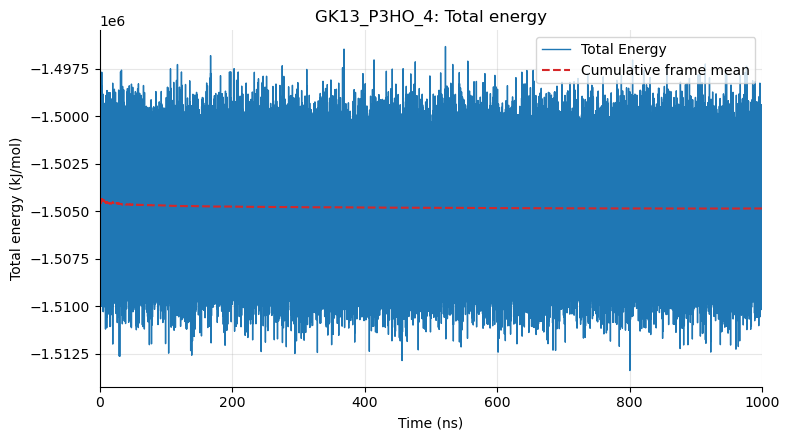

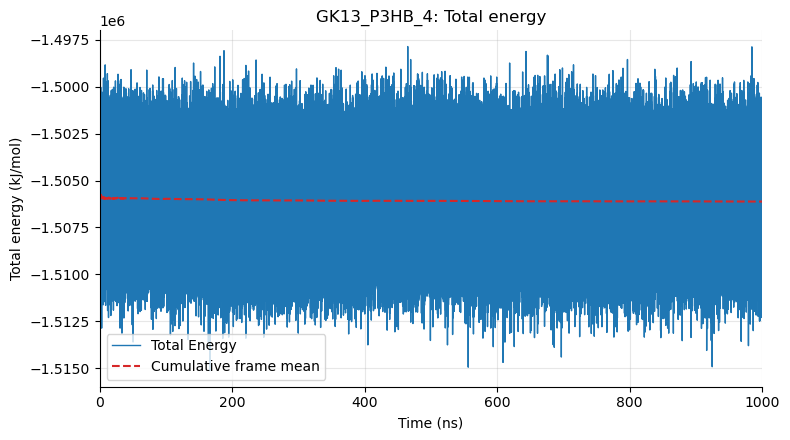

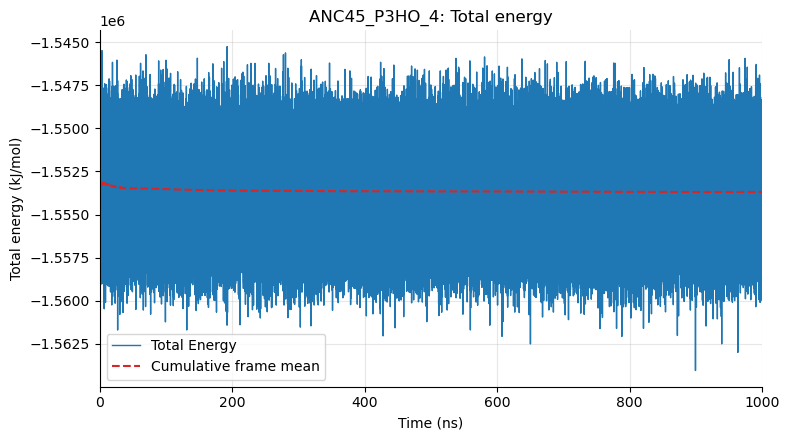

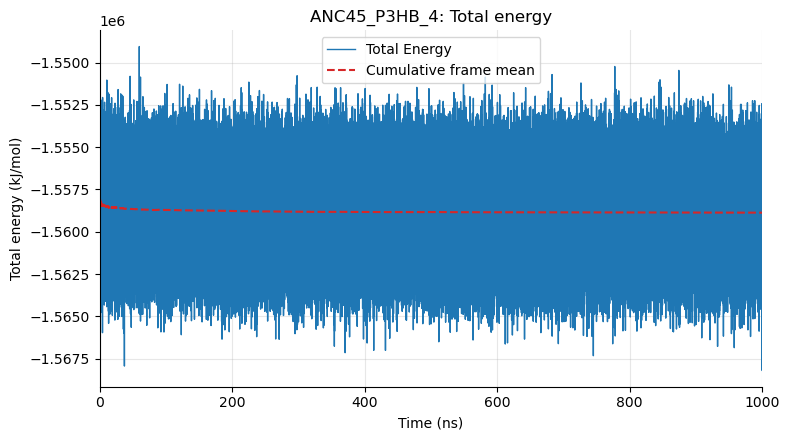

In [19]:
# Figure 1 — edit colours, labels, line widths and axes here, then rerun this cell.
for system in PLOT_SYSTEMS:
    data, prefix = load_plot_data(system, "total_energy", "total_energy_kj_mol")
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, data.total_energy_kj_mol, color="tab:blue", linewidth=1.0,
            label="Total Energy")
    ax.plot(data.time_ns, data.total_energy_kj_mol.expanding().mean(),
            color="tab:red", linestyle="--", linewidth=1.5, label="Cumulative frame mean")
    ax.set(xlabel="Time (ns)", ylabel="Total energy (kJ/mol)",
           title=f"{system.removesuffix('_gromacs')}: Total energy", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_total_energy.png", dpi=PNG_DPI)
    display(fig)
    plt.close(fig)


### Figure 2 — protein backbone RMSD

GK13_P3HO_4_gromacs: mean=1.6535 Å; SD=0.2906 Å; final 20% mean=2.0630 Å


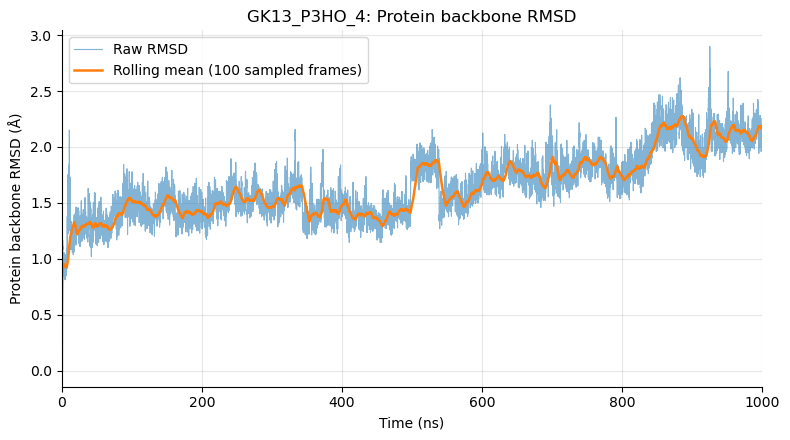

GK13_P3HB_4_gromacs: mean=2.3606 Å; SD=0.6183 Å; final 20% mean=2.5352 Å


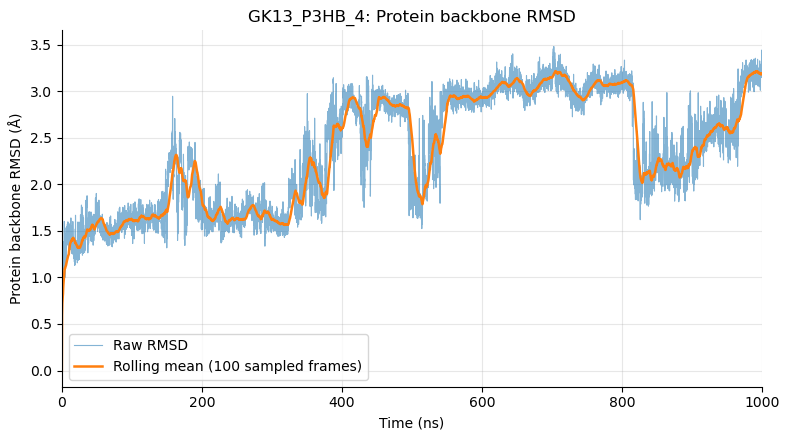

ANC45_P3HO_4_gromacs: mean=2.5093 Å; SD=0.3877 Å; final 20% mean=2.7462 Å


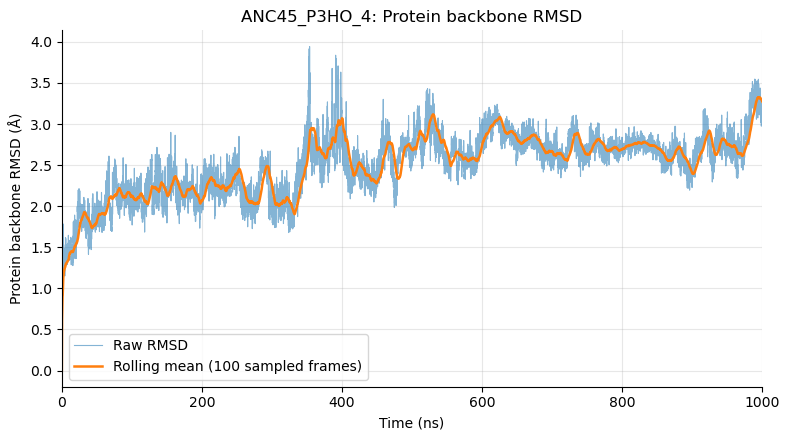

ANC45_P3HB_4_gromacs: mean=2.4210 Å; SD=0.4172 Å; final 20% mean=2.4296 Å


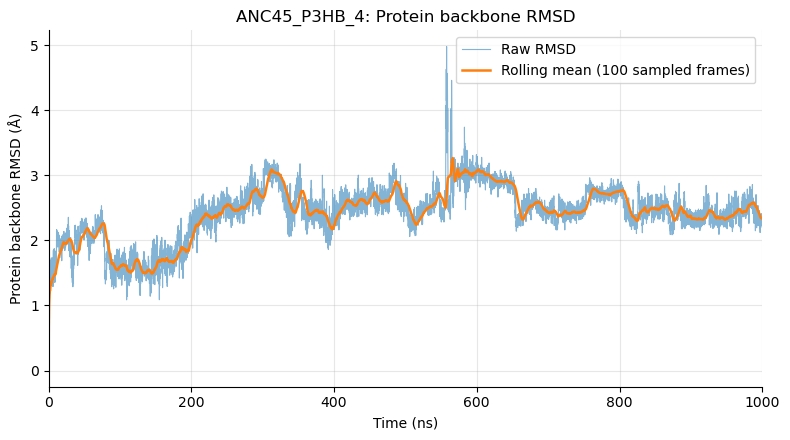

In [36]:
# Figure 2 — edit this cell and rerun it independently of the analysis.
for system in PLOT_SYSTEMS:
    data, prefix = load_plot_data(system, "protein_backbone_rmsd", "protein_backbone_rmsd_A")
    values = data["protein_backbone_rmsd_A"]
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, values, color="tab:blue", linewidth=0.8, alpha=0.55,
            label="Raw RMSD")
    if PLOT_ROLLING_WINDOW is not None:
        mean = values.rolling(PLOT_ROLLING_WINDOW, min_periods=1).mean()
        ax.plot(data.time_ns, mean, color="tab:orange", linewidth=1.8,
                label=f"Rolling mean ({PLOT_ROLLING_WINDOW} sampled frames)")
    ax.set(xlabel="Time (ns)", ylabel="Protein backbone RMSD (Å)",
           title=f"{system.removesuffix('_gromacs')}: Protein backbone RMSD", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_protein_backbone_rmsd.png", dpi=PNG_DPI)
    final_count = max(1, int(np.ceil(0.20 * len(values))))
    print(f"{system}: mean={values.mean():.4f} Å; SD={values.std():.4f} Å; "
          f"final 20% mean={values.iloc[-final_count:].mean():.4f} Å")
    display(fig)
    plt.close(fig)


### Figure 3 — minimum enzyme–PHA distance

GK13_P3HO_4_gromacs: mean=8.1787 Å; SD=11.0233 Å; final 20% mean=10.0559 Å


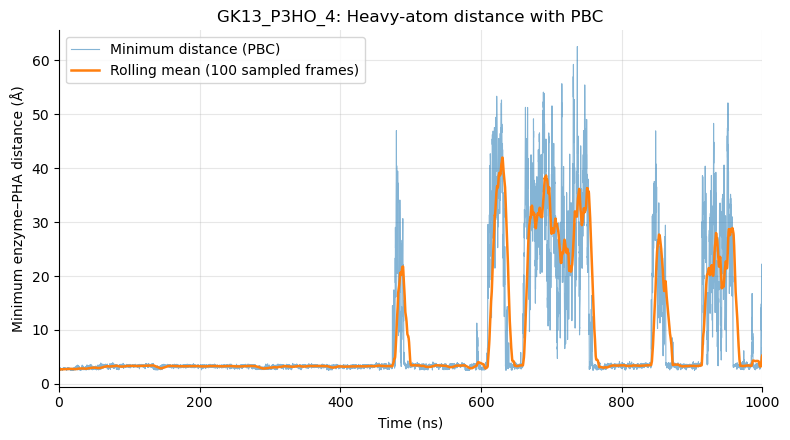

GK13_P3HB_4_gromacs: mean=22.1097 Å; SD=15.2572 Å; final 20% mean=25.4576 Å


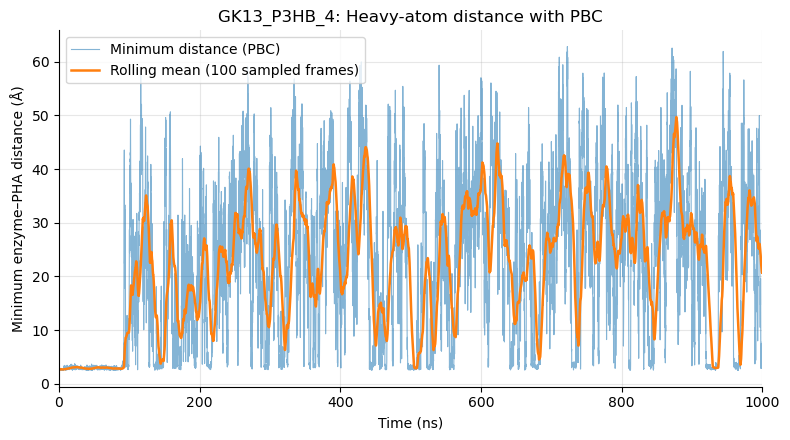

ANC45_P3HO_4_gromacs: mean=8.4539 Å; SD=12.4673 Å; final 20% mean=22.6743 Å


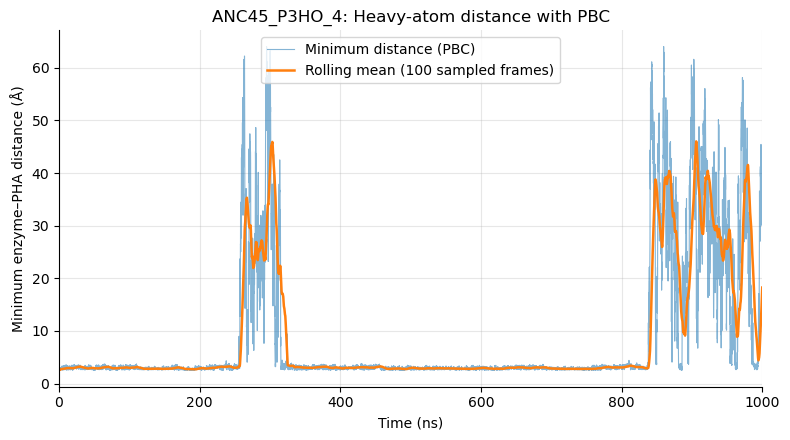

ANC45_P3HB_4_gromacs: mean=25.0709 Å; SD=15.3694 Å; final 20% mean=23.5907 Å


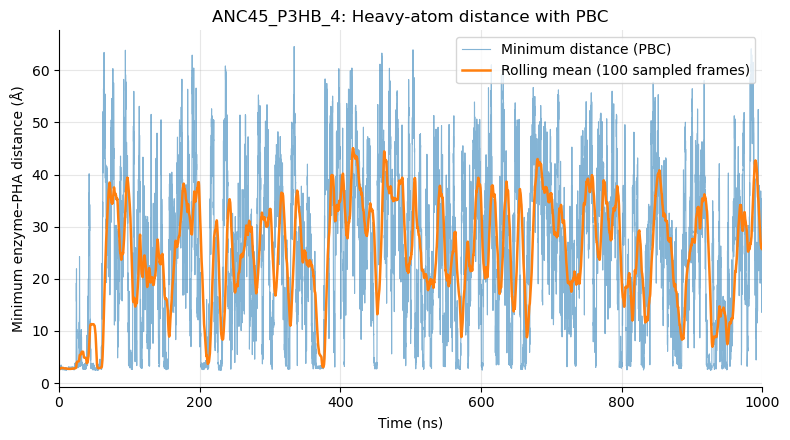

In [37]:
# Figure 3 — edit this cell and rerun it independently of the analysis.
for system in PLOT_SYSTEMS:
    data, prefix = load_plot_data(system, "enzyme_pha_min_distance", "enzyme_pha_min_distance_A")
    values = data["enzyme_pha_min_distance_A"]
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, values, color="tab:blue", linewidth=0.8, alpha=0.55,
            label="Minimum distance (PBC)")
    if PLOT_ROLLING_WINDOW is not None:
        mean = values.rolling(PLOT_ROLLING_WINDOW, min_periods=1).mean()
        ax.plot(data.time_ns, mean, color="tab:orange", linewidth=1.8,
                label=f"Rolling mean ({PLOT_ROLLING_WINDOW} sampled frames)")
    ax.set(xlabel="Time (ns)", ylabel="Minimum enzyme–PHA distance (Å)",
           title=f"{system.removesuffix('_gromacs')}: Heavy-atom distance with PBC", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_enzyme_pha_min_distance.png", dpi=PNG_DPI)
    final_count = max(1, int(np.ceil(0.20 * len(values))))
    print(f"{system}: mean={values.mean():.4f} Å; SD={values.std():.4f} Å; "
          f"final 20% mean={values.iloc[-final_count:].mean():.4f} Å")
    display(fig)
    plt.close(fig)


### Figure 4 — time within a 10 Å minimum-distance cutoff

This **separate cell uses the existing Figure 3 CSVs only**. After restarting the kernel, run **1. Paths**, **5. Plot settings**, then this cell. Leave `RUN_ANALYSIS=False`; no trajectories or energy files are opened.

Edit `DISTANCE_CUTOFF_A = 10.0` below to try a different initial cutoff. A system is **within** when its **raw minimum enzyme–PHA heavy-atom distance ≤ cutoff**. Rolling means are not used for this calculation.

For each system, estimate the duration within the cutoff over the same **0–1000 ns** window, then calculate **100 × within time / total elapsed time**. Between neighbouring saved samples, assume the distance varies linearly and estimate the threshold-crossing time. This weights intervals by their duration instead of counting frames, and works with uneven time spacing. It cannot recover brief excursions between saved samples.

The bar chart compares the four individual trajectories; labels show both percentage and estimated ns. This is a descriptive proximity comparison, not a binding definition or a test of statistical significance. Independent replicate simulations would be needed to assess reproducibility of differences.

The PNG and summary CSV are saved together in `PHA_Enzyme/analysis/` (the shared parent folder), with the cutoff in their filenames. Rerunning this cell replaces only those derived comparison files; existing per-system results are unchanged. Set `SAVE_WITHIN_COMPARISON=False` to preview only.

,system,cutoff_A,within_time_ns,total_time_ns,percent_within
0,GK13_P3HB_4,3,95.027,1000.0,9.503
1,GK13_P3HO_4,3,162.337,1000.0,16.234
2,ANC45_P3HB_4,3,52.192,1000.0,5.219
3,ANC45_P3HO_4,3,485.627,1000.0,48.563


Saved /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/analysis/enzyme_pha_research_0_1000ns_within_3A_comparison.png and .csv


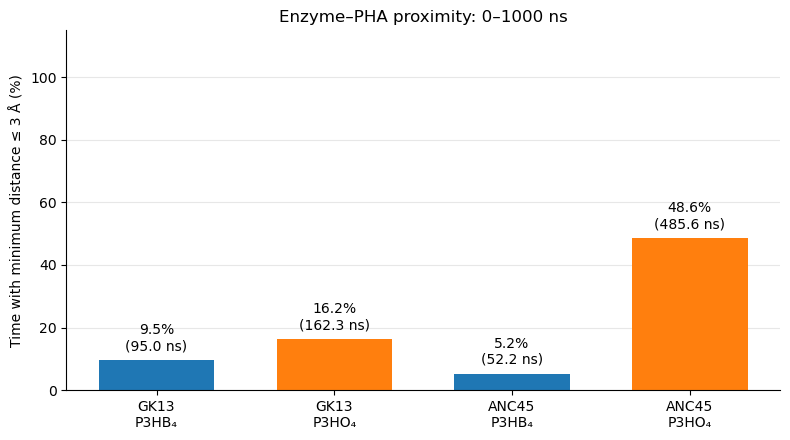

In [40]:
# Figure 4 — change this cutoff and rerun this cell; no trajectory recomputation.
DISTANCE_CUTOFF_A = 3
SAVE_WITHIN_COMPARISON = True
WITHIN_OUTPUT_DIR = BASE_DIR / "analysis"
WITHIN_SYSTEMS = [
    "GK13_P3HB_4_gromacs", "GK13_P3HO_4_gromacs",
    "ANC45_P3HB_4_gromacs", "ANC45_P3HO_4_gromacs",
]


def duration_within_cutoff(time_ns, distance_A, cutoff_A):
    """Integrate time at or below cutoff, with linear interpolation between samples."""
    time_ns = np.asarray(time_ns, dtype=float)
    distance_A = np.asarray(distance_A, dtype=float)
    if (time_ns.ndim != 1 or distance_A.shape != time_ns.shape or len(time_ns) < 2
            or not np.isfinite(time_ns).all() or not np.isfinite(distance_A).all()
            or np.any(distance_A < 0) or not np.isfinite(cutoff_A) or cutoff_A <= 0):
        raise ValueError("Require at least two finite times/distances and a positive Å cutoff.")
    dt = np.diff(time_ns)
    if np.any(dt <= 0):
        raise ValueError("Sample times must be strictly increasing.")
    left, right = distance_A[:-1], distance_A[1:]
    inside_left, inside_right = left <= cutoff_A, right <= cutoff_A
    fraction = (inside_left & inside_right).astype(float)
    crossing = inside_left != inside_right
    crossing_position = (cutoff_A - left[crossing]) / (right[crossing] - left[crossing])
    fraction[crossing] = np.where(inside_left[crossing], crossing_position, 1 - crossing_position)
    return float(np.sum(dt * np.clip(fraction, 0, 1)))


import hashlib
within_rows = []
for system in WITHIN_SYSTEMS:
    data, prefix = load_plot_data(system, "enzyme_pha_min_distance", "enzyme_pha_min_distance_A")
    if not np.allclose([data.time_ns.iloc[0], data.time_ns.iloc[-1]],
                       [START_NS, END_NS], atol=1e-8, rtol=0):
        raise ValueError(f"{system}: CSV must cover the entire common window; no extrapolation.")
    total_ns = float(data.time_ns.iloc[-1] - data.time_ns.iloc[0])
    within_ns = duration_within_cutoff(data.time_ns, data.enzyme_pha_min_distance_A, DISTANCE_CUTOFF_A)
    source_csv = Path(f"{prefix}_enzyme_pha_min_distance.csv")
    within_rows.append({
        "system": system.removesuffix("_gromacs"), "cutoff_A": DISTANCE_CUTOFF_A,
        "start_ns": float(data.time_ns.iloc[0]), "end_ns": float(data.time_ns.iloc[-1]),
        "within_time_ns": within_ns, "total_time_ns": total_ns,
        "percent_within": 100 * within_ns / total_ns, "sample_count": len(data),
        "min_sample_spacing_ns": float(data.time_ns.diff().dropna().min()),
        "max_sample_spacing_ns": float(data.time_ns.diff().dropna().max()),
        "method": "raw minimum distance <= cutoff; linear crossing interpolation",
        "source_csv": str(source_csv),
        "source_csv_sha256": hashlib.sha256(source_csv.read_bytes()).hexdigest(),
    })
within_summary = pd.DataFrame(within_rows)
display(within_summary[["system", "cutoff_A", "within_time_ns", "total_time_ns", "percent_within"]].round(3))

# Edit the comparison plot here without rerunning any MD calculations.
labels = [name.replace("_P3HB_4", "\nP3HB₄").replace("_P3HO_4", "\nP3HO₄")
          for name in within_summary.system]
colours = ["tab:blue" if "P3HB" in name else "tab:orange" for name in within_summary.system]
fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(labels, within_summary.percent_within, color=colours, width=0.65)
for bar, row in zip(bars, within_summary.itertuples()):
    ax.annotate(f"{row.percent_within:.1f}%\n({row.within_time_ns:.1f} ns)",
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", va="bottom")
ax.set(ylabel=f"Time with minimum distance ≤ {DISTANCE_CUTOFF_A:g} Å (%)",
       title=f"Enzyme–PHA proximity: {START_NS:g}–{END_NS:g} ns", ylim=(0, 115))
ax.set_yticks(np.arange(0, 101, 20))
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
if SAVE_WITHIN_COMPARISON:
    WITHIN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    cutoff_tag = f"{DISTANCE_CUTOFF_A:g}".replace(".", "p")
    within_prefix = WITHIN_OUTPUT_DIR / f"enzyme_pha_{OUTPUT_TAG}_within_{cutoff_tag}A_comparison"
    within_summary.to_csv(f"{within_prefix}.csv", index=False)
    fig.savefig(f"{within_prefix}.png", dpi=PNG_DPI)
    print(f"Saved {within_prefix}.png and .csv")
display(fig)
plt.close(fig)


## 6. Inspect and rerun

Each system's `analysis/` folder now contains `<system>_<OUTPUT_TAG>_total_energy.png/.csv`,
`..._protein_backbone_rmsd.png/.csv`, and `..._enzyme_pha_min_distance.png/.csv`, with the rolling-mean columns included in the RMSD/distance CSVs, plus an energy command log and a summary recording the selection and numerical checks.

A low minimum distance reports the closest atom pair, not how many contacts exist or whether the polymer is bound. Energy is a diagnostic; NPT total energy need not be conserved. No equilibration or convergence conclusion is made automatically. A stride of 100 can miss short-lived distance changes: reduce `STRIDE` and choose a new `OUTPUT_TAG` when finer sampling is needed.

Methods: [GROMACS energy](https://manual.gromacs.org/current/onlinehelp/gmx-energy.html),
[MDAnalysis RMSD](https://docs.mdanalysis.org/stable/documentation_pages/analysis/rms.html),
[periodic distance arrays](https://docs.mdanalysis.org/stable/documentation_pages/lib/distances.html).


The revised files use `<system>_research_0_1000ns_*`. Both RMSD and Figure 3 minimum distance are plotted and exported in Å. Energy remains in kJ/mol. Rolling means average the sampled per-frame minima and do not change their definition.

**To edit a plot after restarting the kernel:** run **1. Paths**, then **5. Plot settings**, then the individual **Figure 1, 2 or 3** code cell. You can skip sections 2–4. Change colours, labels, line widths and axes directly in that figure cell. Set `SAVE_FIGURES=False` to preview without saving. All plots keep the left/bottom borders and hide the top/right borders.

`PLOT_ROLLING_WINDOW` changes only the plotted rolling mean, recomputed cheaply from the saved per-frame values. Existing CSV rolling-mean columns still describe the original `ROLLING_WINDOW_FRAMES` recorded in the analysis summary. Changing trajectory stride, selections or calculation window requires running analysis again with a new output tag.

## 7. Residue–PHA distances for Figures 5 and 6

**Run only the new sections:** after a kernel restart, run **1. Paths**, **5. Plot settings**, then sections **7–9** below. Do not run Figures 1–4. The new sections reuse `SYSTEMS`, selections, `STRIDE`, `START_NS`, `END_NS`, `OUTPUT_TAG`, fonts and PNG settings. The supplied Figure 3 CSVs have **10,001 samples, 0.1 ns apart, over 0–1000 ns** (`STRIDE=1`). The frame indices, timestamps, selection counts and input provenance are checked before comparison.

Existing Figure 3 data contain only overall minima. The older GK13–P3HB catalytic-triad CSV uses selected side-chain atoms and polymer subsets including hydrogen atoms; it is not compatible with all-residue heavy-atom distances. Therefore each missing residue distance is calculated once from the full processed trajectory.

For every sampled frame, take the minimum PBC distance from **each protein residue's heavy atoms** to **all PHA heavy atoms**, using the original coordinates and that frame's box. Heavy atoms are TPR masses >3 u, exactly as in Figure 3. There is no fitting, centring or transformation here. The minimum over all residues must reproduce Figure 3 in every frame. No old figure or result file is rewritten.

**Calculate once:** set `RUN_RESIDUE_CALCULATION=True` below. Complete compatible caches are reused; `OVERWRITE_RESIDUE_DATA=False` protects existing data. Afterwards leave the calculation flag `False` to plot or change cutoffs using the saved CSVs. Both requested cutoffs, **3.5 Å and 3.0 Å**, are configured together. These are **distance-defined contacts, not confirmed hydrogen bonds**.

In [3]:
RUN_RESIDUE_CALCULATION = False
OVERWRITE_RESIDUE_DATA = False
RESIDUE_CUTOFFS_A = (3.5, 3.0)
RESIDUE_SYSTEMS = list(SYSTEMS)
RESIDUE_COMPARISON_DIR = BASE_DIR / "analysis"
SAVE_RESIDUE_FIGURES = True  # Saves the new PNGs and their supporting CSVs only.
PANEL_FIGSIZE = (2 * FIGSIZE[0], 2 * FIGSIZE[1])  # Four panels, each using the existing 8 × 4.5 inch size.
FIGURE3_TOLERANCE_A = 2e-5

import hashlib
from matplotlib.colors import ListedColormap, BoundaryNorm

if len(RESIDUE_SYSTEMS) != 4 or len(set(RESIDUE_SYSTEMS)) != 4:
    raise ValueError("Figures 5 and 6 require four distinct configured systems.")
if not RESIDUE_CUTOFFS_A or any(not np.isfinite(c) or c <= 0 for c in RESIDUE_CUTOFFS_A):
    raise ValueError("Contact cutoffs must be positive finite Å values.")


def residue_paths(system):
    folder = BASE_DIR / system
    prefix = folder / "analysis" / f"{system.removesuffix('_gromacs')}_{OUTPUT_TAG}"
    return {"prefix": prefix, "tpr": folder / "step7_production.tpr",
            "xtc": folder / "analysis" / TRAJECTORY_NAME,
            "figure3": Path(f"{prefix}_enzyme_pha_min_distance.csv"),
            "figure3_summary": Path(f"{prefix}_summary.json"),
            "distances": Path(f"{prefix}_residue_pha_distances_A.csv"),
            "residues": Path(f"{prefix}_residue_pha_residues.csv"),
            "metadata": Path(f"{prefix}_residue_pha_metadata.json")}


def residue_input_stats(paths):
    return {key: [paths[key].stat().st_size, paths[key].stat().st_mtime_ns] for key in ("tpr", "xtc")}


def file_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


def figure3_for_residues(system):
    paths = residue_paths(system)
    data = pd.read_csv(paths["figure3"])
    meta = json.loads(paths["figure3_summary"].read_text())
    columns = ["frame", "time_ns", "enzyme_pha_min_distance_A"]
    data = data[columns].copy()
    if len(data) < 2 or not np.isfinite(data.to_numpy()).all() or (data.enzyme_pha_min_distance_A < 0).any():
        raise ValueError(f"{system}: invalid Figure 3 data.")
    if not np.equal(data.frame, np.floor(data.frame)).all():
        raise ValueError("Figure 3 frame indices must be integers.")
    data["frame"] = data.frame.astype(int)
    if data.frame.iloc[0] != 0 or not (np.diff(data.frame) == STRIDE).all() or np.any(np.diff(data.time_ns) <= 0):
        raise ValueError(f"{system}: Figure 3 sampling differs from STRIDE={STRIDE}.")
    if not np.allclose([data.time_ns.iloc[0], data.time_ns.iloc[-1]], [START_NS, END_NS], atol=1e-8, rtol=0):
        raise ValueError(f"{system}: Figure 3 does not cover the full comparison window.")
    if (meta["selections"]["protein"] != PROTEIN_SELECTION or meta["selections"]["pha"] != PHA_SELECTION
            or meta["selections"]["heavy"] != "TPR mass > 3 u" or meta["stride"] != STRIDE
            or meta["units"]["minimum_distance"] != "Å" or meta["units"]["time"] != "ns"):
        raise ValueError(f"{system}: incompatible Figure 3 selections, sampling or units.")
    stats = residue_input_stats(paths)
    for key in ("tpr", "xtc"):
        if paths[key].resolve() != Path(meta["inputs"][key]).resolve() or stats[key] != meta["input_size_mtime_ns"][key]:
            raise ValueError(f"{system}: {key} differs from the Figure 3 input.")
    return paths, data, meta


def load_residue_distances(system):
    paths, figure3, previous = figure3_for_residues(system)
    meta = json.loads(paths["metadata"].read_text())
    expected = {"protein": PROTEIN_SELECTION, "pha": PHA_SELECTION, "heavy": "TPR mass > 3 u"}
    if (meta["selections"] != expected or meta["stride"] != STRIDE
            or meta["window_ns"] != [START_NS, END_NS] or meta["units"] != {"time": "ns", "distance": "Å"}
            or meta["input_size_mtime_ns"] != residue_input_stats(paths)
            or meta["figure3_sha256"] != file_sha256(paths["figure3"])):
        raise ValueError(f"{system}: residue cache settings/provenance differ; calculate a new cache.")
    if meta["distance_csv_sha256"] != file_sha256(paths["distances"]) or meta["residue_csv_sha256"] != file_sha256(paths["residues"]):
        raise ValueError(f"{system}: a cached CSV changed after validation.")
    residues = pd.read_csv(paths["residues"], keep_default_na=False)
    data = pd.read_csv(paths["distances"])
    columns = residues.distance_column.tolist()
    if data.columns.tolist() != ["frame", "time_ns"] + columns or len(set(columns)) != len(columns):
        raise ValueError("Residue identifiers do not match distance columns.")
    if not np.array_equal(data.frame, figure3.frame) or not np.allclose(data.time_ns, figure3.time_ns, atol=1e-8, rtol=0):
        raise ValueError("Residue cache frames/times differ from Figure 3.")
    distances = data[columns].to_numpy(dtype=float)
    if not np.isfinite(distances).all() or np.any(distances < 0):
        raise ValueError("Invalid residue distances.")
    if not np.allclose(distances.min(axis=1), figure3.enzyme_pha_min_distance_A, atol=FIGURE3_TOLERANCE_A, rtol=0):
        raise ValueError("Residue minima do not reproduce Figure 3.")
    if residues.resid.duplicated().any() or not np.equal(residues.resid, np.floor(residues.resid)).all():
        raise ValueError("Plots require unique integer residue numbers; split chains if numbering overlaps.")
    return data, residues, meta


### 7a. Calculate or reuse residue distances

This cell streams one trajectory frame at a time. It stores a small frame × residue distance matrix, not the full trajectory. Distance CSV columns identify each residue; the companion residue table records its original `resid`, `resname`, `segid`, topology `resindex`, heavy-atom count and atom names. The metadata JSON records exact frames/sampling, input fingerprints, selections, Å/ns units and all-frame Figure 3 validation. The 0, 500 and 1000 ns frames also receive an independent minimum-image check for the inspected orthorhombic boxes.

In [4]:
if RUN_RESIDUE_CALCULATION:
    from tempfile import TemporaryDirectory
    import MDAnalysis as mda
    from MDAnalysis.lib.distances import distance_array
    from MDAnalysis.lib.mdamath import triclinic_vectors

    # Complete validation of existing destinations before beginning any new calculation.
    pending = []
    for system in RESIDUE_SYSTEMS:
        paths, figure3, previous = figure3_for_residues(system)
        exists = [paths[k].exists() or paths[k].is_symlink() for k in ("distances", "residues", "metadata")]
        if any(exists) and not OVERWRITE_RESIDUE_DATA:
            if not all(exists):
                raise FileExistsError(f"{system}: incomplete residue cache; inspect it before explicitly enabling overwrite.")
            load_residue_distances(system)
            print(f"{system}: validated existing residue cache; reusing it.", flush=True)
        else:
            pending.append(system)

    for system in pending:
        paths, figure3, previous = figure3_for_residues(system)
        before = residue_input_stats(paths)
        figure3_hash = file_sha256(paths["figure3"])
        print(f"{system}: calculating {len(figure3)} sampled frames", flush=True)
        with TemporaryDirectory(prefix="ipha_residue_contacts_") as scratch:
            linked_xtc = Path(scratch) / "trajectory.xtc"
            linked_xtc.symlink_to(paths["xtc"])
            u = mda.Universe(str(paths["tpr"]), str(linked_xtc))
            try:
                protein = u.select_atoms(PROTEIN_SELECTION)
                pha = u.select_atoms(PHA_SELECTION)
                heavy = protein[protein.masses > 3]
                pha_heavy = pha[pha.masses > 3]
                if (len(u.atoms) != u.trajectory.n_atoms or len(protein.fragments) != 1
                        or not len(heavy) or not len(pha_heavy) or np.intersect1d(heavy.indices, pha_heavy.indices).size):
                    raise ValueError("Invalid topology/trajectory or overlapping/empty atom selections.")
                counts = {"system_atoms": len(u.atoms), "protein_atoms": len(protein),
                          "protein_residues": len(protein.residues), "protein_heavy_atoms": len(heavy),
                          "pha_atoms": len(pha), "pha_heavy_atoms": len(pha_heavy)}
                if any(value != previous["counts"][key] for key, value in counts.items()):
                    raise ValueError("Selection counts differ from Figure 3.")
                pha_identity = [{"resid": int(r.resid), "resname": str(r.resname), "segid": str(r.segid)} for r in pha.residues]
                if pha_identity != previous["counts"]["pha_identity"]:
                    raise ValueError("PHA residue identity differs from Figure 3.")
                for group in (heavy, pha_heavy):
                    if not np.isfinite(group.masses).all() or not np.isin(group.names.astype(str).astype('U1'), ['C','N','O','S']).all():
                        raise ValueError("Unexpected retained heavy-atom names/masses; inspect the topology.")
                resindices, starts = np.unique(heavy.resindices, return_index=True)
                if np.any(np.diff(heavy.resindices) < 0) or not np.array_equal(resindices, protein.residues.resindices):
                    raise ValueError("Every protein residue must have an ordered heavy-atom group.")
                residues = []
                for index in resindices:
                    residue = u.residues[index]
                    atoms = heavy[heavy.resindices == index]
                    residues.append({"distance_column": f"resindex_{index}_{residue.resname}{residue.resid}_A",
                                     "resindex": int(index), "resid": int(residue.resid),
                                     "resname": str(residue.resname), "segid": str(residue.segid),
                                     "heavy_atom_count": len(atoms), "heavy_atom_names": " ".join(atoms.names)})
                residues = pd.DataFrame(residues)
                if residues.resid.duplicated().any():
                    raise ValueError("Multiple chains share residue numbers; a chain-specific plot is required.")
                values = np.empty((len(figure3), len(residues)), dtype=float)
                pair_buffer = np.empty((len(heavy), len(pha_heavy)), dtype=np.float64)
                frame_checks, max_error = [], 0.0
                for row_number, row in enumerate(figure3.itertuples(index=False)):
                    ts = u.trajectory[int(row.frame)]
                    if not np.isclose(ts.time / 1000, row.time_ns, atol=1e-8, rtol=0):
                        raise ValueError(f"Frame/time mismatch at {row.frame}.")
                    box = ts.dimensions.copy() if ts.dimensions is not None else None
                    if box is None or not np.isfinite(box).all() or np.any(box[:3] <= 0) or np.linalg.det(triclinic_vectors(box)) <= 0:
                        raise ValueError(f"Invalid box at frame {row.frame}.")
                    enzyme_xyz, pha_xyz = heavy.positions.copy(), pha_heavy.positions.copy()
                    if not np.isfinite(enzyme_xyz).all() or not np.isfinite(pha_xyz).all():
                        raise ValueError("Non-finite coordinates.")
                    # Original coordinates + same-frame box, with no RMSD fitting or transformations.
                    distance_array(enzyme_xyz, pha_xyz, box=box, result=pair_buffer)
                    per_atom_minimum = pair_buffer.min(axis=1)
                    values[row_number] = np.minimum.reduceat(per_atom_minimum, starts)
                    error = abs(float(values[row_number].min()) - row.enzyme_pha_min_distance_A)
                    max_error = max(max_error, error)
                    if error > FIGURE3_TOLERANCE_A:
                        raise ValueError(f"Residue minima differ from Figure 3 at frame {row.frame}: {error} Å.")
                    if not np.array_equal(heavy.positions, enzyme_xyz) or not np.array_equal(ts.dimensions, box):
                        raise AssertionError("Coordinates or box changed during distance calculation.")
                    if row_number in {0, len(figure3)//2, len(figure3)-1}:
                        if not np.allclose(box[3:], 90, atol=1e-4):
                            raise ValueError("Independent check expects the inspected orthorhombic boxes.")
                        delta = enzyme_xyz.astype(float)[:, None, :] - pha_xyz.astype(float)[None, :, :]
                        delta -= box[:3] * np.rint(delta / box[:3])
                        independent = np.minimum.reduceat(np.linalg.norm(delta, axis=2).min(axis=1), starts)
                        check_error = float(np.max(np.abs(independent - values[row_number])))
                        assert check_error < 2e-5
                        frame_checks.append({"frame": int(row.frame), "time_ns": float(row.time_ns),
                                             "max_residue_error_A": check_error})
                    if row_number % 2000 == 0:
                        print(f"  {row_number + 1}/{len(figure3)} frames; Figure 3 max error {max_error:.3g} Å", flush=True)
                atom_ids = {"protein_heavy_atom_indices": heavy.indices.tolist(), "pha_heavy_atom_indices": pha_heavy.indices.tolist()}
            finally:
                u.trajectory.close()
        if residue_input_stats(paths) != before or file_sha256(paths["figure3"]) != figure3_hash:
            raise RuntimeError("A source file changed during calculation.")
        result = pd.DataFrame(values, columns=residues.distance_column)
        result.insert(0, "time_ns", figure3.time_ns.to_numpy())
        result.insert(0, "frame", figure3.frame.to_numpy())
        result.to_csv(paths["distances"], index=False, float_format="%.8f")
        residues.to_csv(paths["residues"], index=False)
        steps = np.diff(figure3.time_ns)
        metadata = {"system": system, "inputs": {k: str(paths[k]) for k in ("tpr", "xtc")},
                    "input_size_mtime_ns": before, "figure3_csv": str(paths["figure3"]),
                    "figure3_sha256": figure3_hash, "selections": {"protein": PROTEIN_SELECTION,
                    "pha": PHA_SELECTION, "heavy": "TPR mass > 3 u"}, "counts": counts,
                    "pha_identity": pha_identity, **atom_ids, "units": {"time": "ns", "distance": "Å"},
                    "stride": STRIDE, "window_ns": [START_NS, END_NS], "sample_count": len(result),
                    "frame_start": int(figure3.frame.iloc[0]), "frame_end": int(figure3.frame.iloc[-1]),
                    "sampling_interval_ns": {"min": float(steps.min()), "max": float(steps.max()),
                                             "uniform": bool(np.allclose(steps, steps[0], atol=1e-8, rtol=0))},
                    "pbc": "minimum image with each frame's original box; unaligned coordinates",
                    "distance_definition": "minimum over residue heavy atoms and all PHA heavy atoms",
                    "figure3_validation_frames": len(result), "figure3_max_abs_error_A": max_error,
                    "independent_checks": frame_checks, "MDAnalysis_version": mda.__version__,
                    "distance_csv_sha256": file_sha256(paths["distances"]),
                    "residue_csv_sha256": file_sha256(paths["residues"])}
        paths["metadata"].write_text(json.dumps(metadata, indent=2) + "\n")
        print(f"Saved residue distances, identifiers and settings: {paths['prefix']}_residue_pha_*", flush=True)
        del result, values
else:
    print("Residue trajectory calculation skipped. Plotting below reads the saved residue CSVs.")


/opt/homebrew/Caskroom/miniconda/base/envs/ipha_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GK13_P3HO_4_gromacs: calculating 10001 sampled frames


  1/10001 frames; Figure 3 max error 0 Å


  2001/10001 frames; Figure 3 max error 4.44e-16 Å


  4001/10001 frames; Figure 3 max error 4.44e-16 Å


...

  4001/10001 frames; Figure 3 max error 7.11e-15 Å


  6001/10001 frames; Figure 3 max error 7.11e-15 Å


  8001/10001 frames; Figure 3 max error 7.11e-15 Å


  10001/10001 frames; Figure 3 max error 7.11e-15 Å


Saved residue distances, identifiers and settings: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HB_4_gromacs/analysis/ANC45_P3HB_4_research_0_1000ns_residue_pha_*


### 7b. Load saved data and apply Figure 4's time convention

No MDAnalysis or trajectory reading is required from this point. All four systems must span the entire common window. Occupancy is **100 × estimated time at or below cutoff / 1000 ns**, including every period when the polymer is away. Each residue is classified once per sample, regardless of the number of atom pairs. Crossing times are linearly interpolated between neighbouring raw distances, exactly as in Figure 4; no rolling means enter contact calculations. The integration is weighted by the actual timestamp differences and also works for uneven sampling.

The binary map in Figure 6 shows the classification **at the saved times**. Time cells extend to adjacent time midpoints (clipped to 0–1000 ns); this visual binning does not replace the interpolated occupancy calculation. White means no contact. Original residue numbers are used, with missing residue numbers masked grey rather than renumbered. All residues and all sampled times remain present.

In [5]:
def residue_duration_within_cutoff(time_ns, distance_A, cutoff_A):
    """Integrate time at or below cutoff, with linear interpolation between samples."""
    time_ns = np.asarray(time_ns, dtype=float)
    distance_A = np.asarray(distance_A, dtype=float)
    if (time_ns.ndim != 1 or distance_A.shape != time_ns.shape or len(time_ns) < 2
            or not np.isfinite(time_ns).all() or not np.isfinite(distance_A).all()
            or np.any(distance_A < 0) or not np.isfinite(cutoff_A) or cutoff_A <= 0):
        raise ValueError("Require at least two finite times/distances and a positive Å cutoff.")
    dt = np.diff(time_ns)
    if np.any(dt <= 0):
        raise ValueError("Sample times must be strictly increasing.")
    left, right = distance_A[:-1], distance_A[1:]
    inside_left, inside_right = left <= cutoff_A, right <= cutoff_A
    fraction = (inside_left & inside_right).astype(float)
    crossing = inside_left != inside_right
    crossing_position = (cutoff_A - left[crossing]) / (right[crossing] - left[crossing])
    fraction[crossing] = np.where(inside_left[crossing], crossing_position, 1 - crossing_position)
    return float(np.sum(dt * np.clip(fraction, 0, 1)))


# Small analytic checks include unequal time intervals and crossing at the cutoff.
assert np.isclose(residue_duration_within_cutoff([0, 3, 10], [2, 2, 5], 3.5), 6.5)
assert residue_duration_within_cutoff([0, 10], [3.5, 3.5], 3.5) == 10
assert residue_duration_within_cutoff([0, 10], [5, 5], 3.5) == 0

residue_cache = {}
for system in RESIDUE_SYSTEMS:
    data, residues, metadata = load_residue_distances(system)
    residue_cache[system] = (data, residues, metadata)
    print(f"{system}: {len(residues)} residues; {len(data)} frames; "
          f"{data.time_ns.iloc[0]:g}–{data.time_ns.iloc[-1]:g} ns; "
          f"sample spacing {metadata['sampling_interval_ns']['min']:g}–{metadata['sampling_interval_ns']['max']:g} ns")


def residue_cutoff_tag(cutoff):
    return f"{cutoff:.1f}".replace(".", "p")


def residue_panel_title(system):
    return system.removesuffix("_gromacs").replace("_P3HB_4", " · P3HB₄").replace("_P3HO_4", " · P3HO₄")


GK13_P3HO_4_gromacs: 245 residues; 10001 frames; 0–1000 ns; sample spacing 0.1–0.1 ns


GK13_P3HB_4_gromacs: 245 residues; 10001 frames; 0–1000 ns; sample spacing 0.1–0.1 ns


ANC45_P3HO_4_gromacs: 244 residues; 10001 frames; 0–1000 ns; sample spacing 0.1–0.1 ns


ANC45_P3HB_4_gromacs: 244 residues; 10001 frames; 0–1000 ns; sample spacing 0.1–0.1 ns


## 8. Figure 5 — Residue–PHA Contact Occupancy

Two four-panel PNGs are generated, one per cutoff. All panels use 0–100% and the full common residue-number range; blue represents P3HB₄ and orange P3HO₄, as in Figure 4. CSVs contain the residue identity, within time, total time, percentage, cutoff and duration-estimation method. The five most occupied residues per system/cutoff are also printed for inspection; the figure includes every residue.

GK13_P3HO_4_gromacs, ≤ 3.5 Å — top residues:


,resid,resname,within_time_ns,percent_within
95,96,ASN,150.388,15.039
169,170,SER,131.366,13.137
91,92,PHE,121.537,12.154
47,48,SER,111.731,11.173
138,139,SER,99.098,9.910


GK13_P3HB_4_gromacs, ≤ 3.5 Å — top residues:

,resid,resname,within_time_ns,percent_within
95,96,ASN,47.375,4.738
47,48,SER,40.033,4.003
91,92,PHE,32.646,3.265
196,197,VAL,29.482,2.948
169,170,SER,29.345,2.934


ANC45_P3HO_4_gromacs, ≤ 3.5 Å — top residues:


,resid,resname,within_time_ns,percent_within
225,226,HSD,331.200,33.120
137,138,SER,312.218,31.222
47,48,SER,193.715,19.372
61,62,PHE,191.433,19.143
141,142,TYR,136.728,13.673


ANC45_P3HB_4_gromacs, ≤ 3.5 Å — top residues:


,resid,resname,within_time_ns,percent_within
47,48,SER,24.110,2.411
225,226,HSD,15.348,1.535
61,62,PHE,13.628,1.363
137,138,SER,12.042,1.204
195,196,ILE,10.707,1.071


Saved /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/analysis/enzyme_pha_research_0_1000ns_figure5_residue_occupancy_3p5A.png and .csv


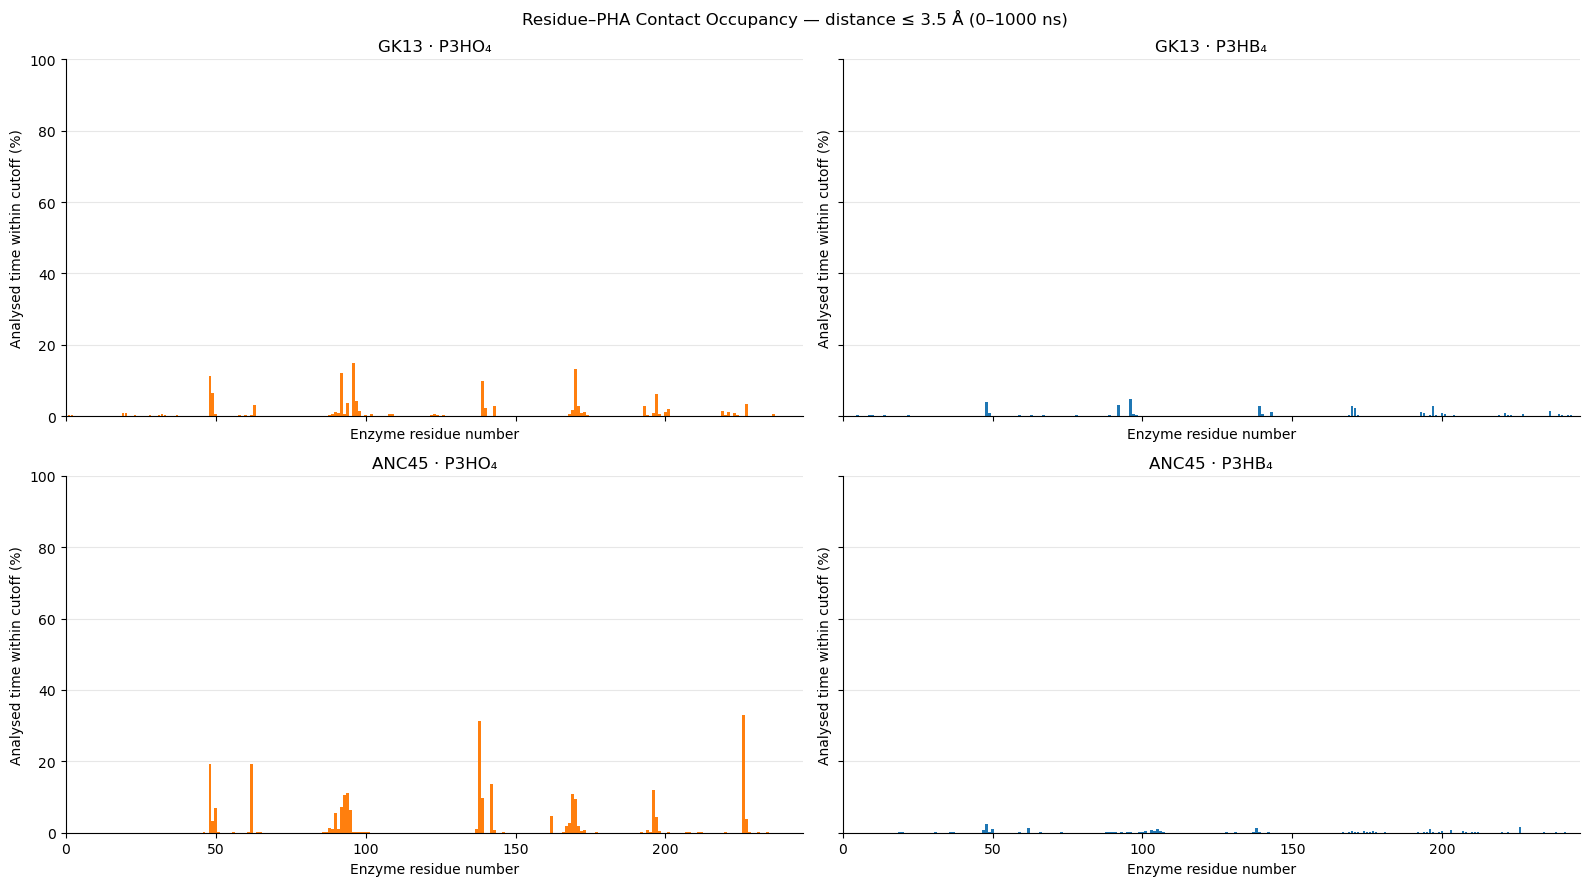

GK13_P3HO_4_gromacs, ≤ 3 Å — top residues:


,resid,resname,within_time_ns,percent_within
169,170,SER,38.029,3.803
47,48,SER,36.125,3.612
95,96,ASN,23.534,2.353
138,139,SER,18.123,1.812
93,94,GLN,9.971,0.997


GK13_P3HB_4_gromacs, ≤ 3 Å — top residues:


,resid,resname,within_time_ns,percent_within
47,48,SER,18.210,1.821
169,170,SER,17.843,1.784
235,236,LYS,9.533,0.953
95,96,ASN,6.758,0.676
196,197,VAL,6.274,0.627


ANC45_P3HO_4_gromacs, ≤ 3 Å — top residues:


,resid,resname,within_time_ns,percent_within
225,226,HSD,166.352,16.635
137,138,SER,64.044,6.404
47,48,SER,58.514,5.851
169,170,GLY,48.277,4.828
93,94,THR,33.623,3.362


ANC45_P3HB_4_gromacs, ≤ 3 Å — top residues:


,resid,resname,within_time_ns,percent_within
47,48,SER,18.799,1.880
202,203,ASP,6.622,0.662
225,226,HSD,3.119,0.312
206,207,ASP,3.082,0.308
72,73,GLU,2.152,0.215


Saved /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/analysis/enzyme_pha_research_0_1000ns_figure5_residue_occupancy_3p0A.png and .csv


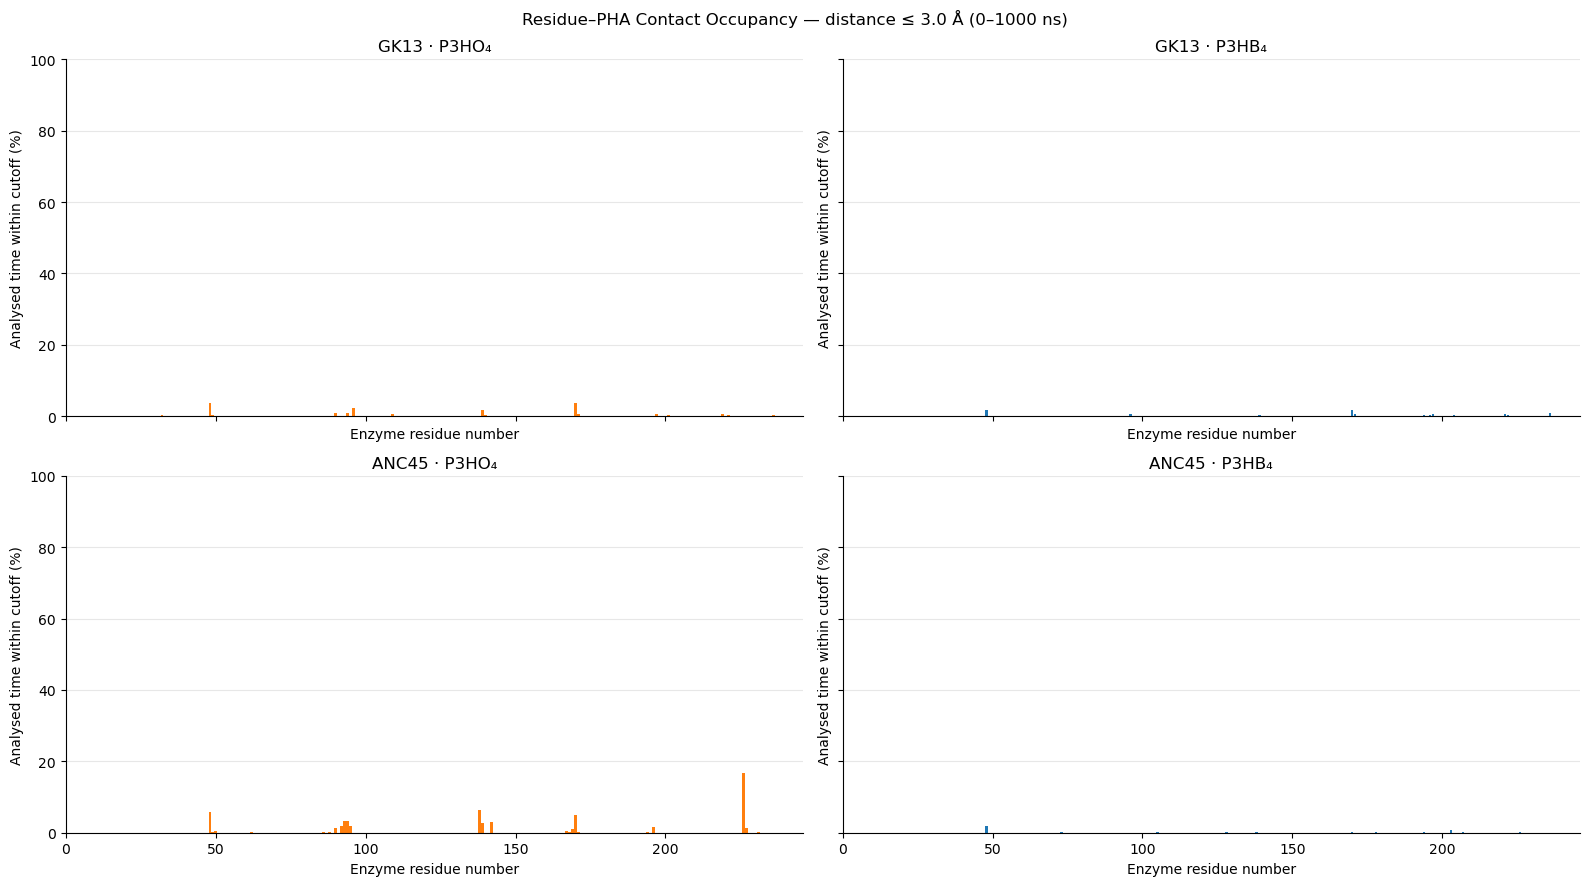

In [6]:
for cutoff in RESIDUE_CUTOFFS_A:
    tag = residue_cutoff_tag(cutoff)
    fig, axes = plt.subplots(2, 2, figsize=PANEL_FIGSIZE, sharex=True, sharey=True)
    tables = []
    residue_min = min(int(residues.resid.min()) for _, residues, _ in residue_cache.values())
    residue_max = max(int(residues.resid.max()) for _, residues, _ in residue_cache.values())
    for ax, system in zip(axes.flat, RESIDUE_SYSTEMS):
        data, residues, metadata = residue_cache[system]
        table = residues.copy()
        table.insert(0, "system", system.removesuffix("_gromacs"))
        table["cutoff_A"] = cutoff
        table["within_time_ns"] = [residue_duration_within_cutoff(data.time_ns, data[column], cutoff)
                                   for column in residues.distance_column]
        table["total_time_ns"] = float(data.time_ns.iloc[-1] - data.time_ns.iloc[0])
        table["percent_within"] = 100 * table.within_time_ns / table.total_time_ns
        table["method"] = "distance <= cutoff; linear interpolation of crossings; full elapsed duration"
        table["source_distances"] = str(residue_paths(system)["distances"])
        tables.append(table)
        colour = "tab:blue" if "P3HB" in system else "tab:orange"
        ax.bar(table.resid, table.percent_within, color=colour, width=0.85)
        ax.set(title=residue_panel_title(system), xlabel="Enzyme residue number",
               ylabel="Analysed time within cutoff (%)", ylim=(0, 100), xlim=(residue_min-1, residue_max+1))
        ax.set_axisbelow(True)
        ax.grid(axis="y", alpha=0.3)
        print(f"{system}, ≤ {cutoff:g} Å — top residues:")
        display(table.nlargest(5, "percent_within")[["resid", "resname", "within_time_ns", "percent_within"]].round(3))
        if SAVE_RESIDUE_FIGURES:
            table.to_csv(f"{residue_paths(system)['prefix']}_residue_pha_occupancy_{tag}A.csv", index=False)
    fig.suptitle(f"Residue–PHA Contact Occupancy — distance ≤ {cutoff:.1f} Å ({START_NS:g}–{END_NS:g} ns)")
    fig.tight_layout()
    if SAVE_RESIDUE_FIGURES:
        RESIDUE_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
        prefix = RESIDUE_COMPARISON_DIR / f"enzyme_pha_{OUTPUT_TAG}_figure5_residue_occupancy_{tag}A"
        pd.concat(tables, ignore_index=True).to_csv(f"{prefix}.csv", index=False)
        fig.savefig(f"{prefix}.png", dpi=PNG_DPI)
        print(f"Saved {prefix}.png and .csv")
    display(fig)
    plt.close(fig)


## 9. Figure 6 — Enzyme–PHA Contacts Over Time

Two four-panel binary maps use **white = no contact** and **blue = contact**. Neither distances nor binary states are smoothed. Per-system supporting CSVs contain `frame`, `time_ns`, and 0/1 contact columns using the same residue identifiers as the distance cache. The shared figure CSV indexes those four tables and records the cutoff, sampling and residue range. Contact-free periods are retained; occupancies are not renormalised to periods when PHA is near the enzyme.

Saved /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/analysis/enzyme_pha_research_0_1000ns_figure6_contacts_over_time_3p5A.png and .csv (index to the four full binary tables)


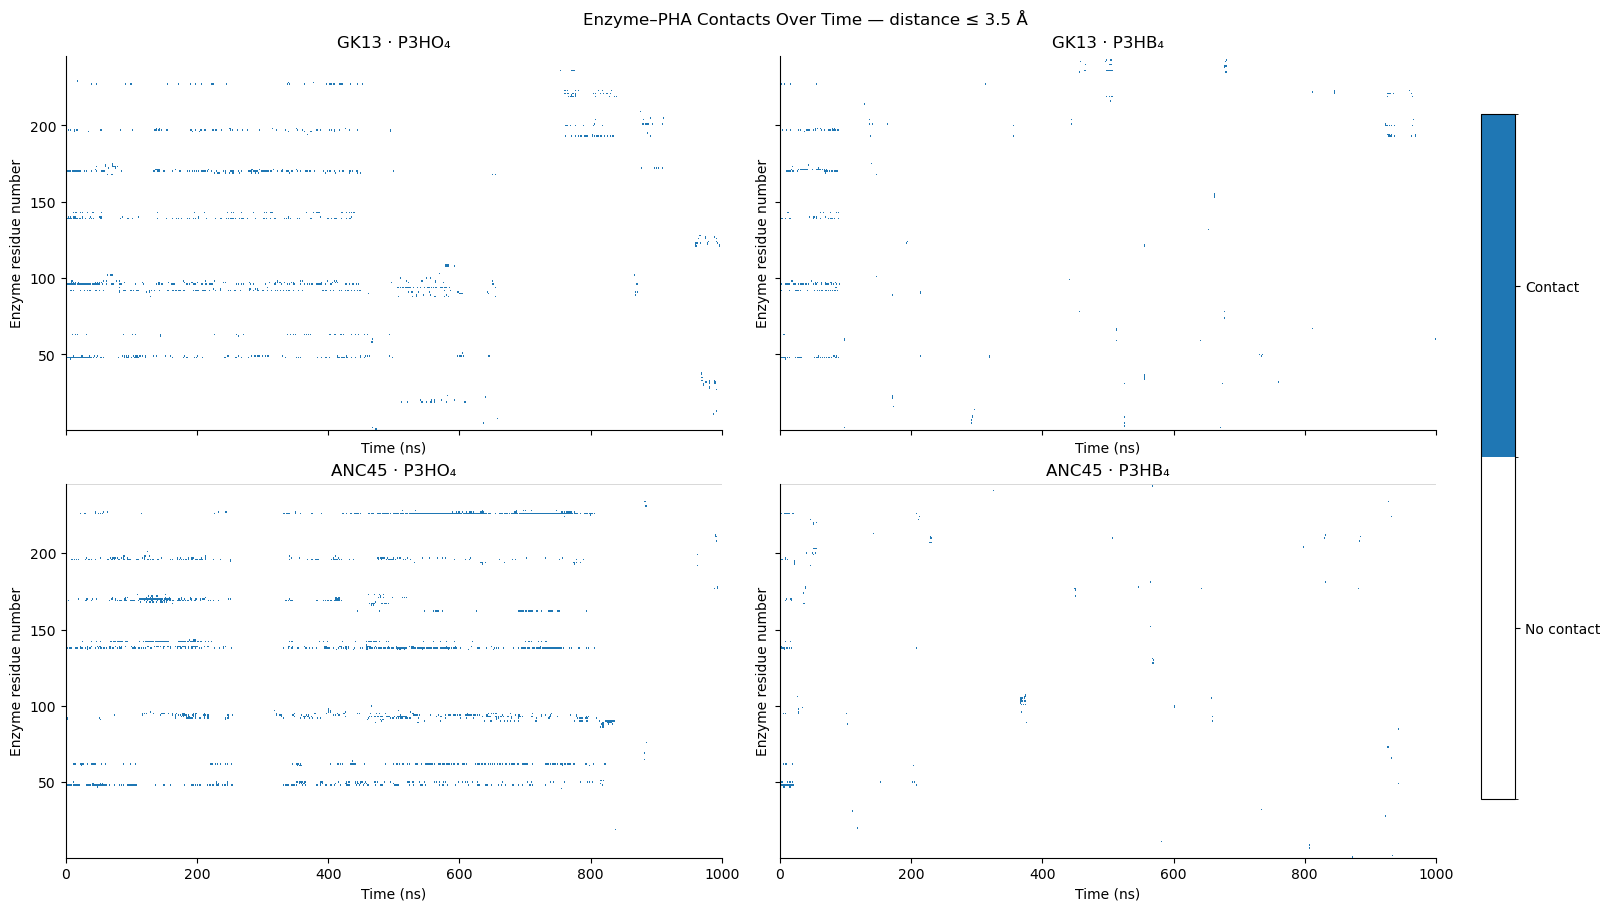

Saved /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/analysis/enzyme_pha_research_0_1000ns_figure6_contacts_over_time_3p0A.png and .csv (index to the four full binary tables)


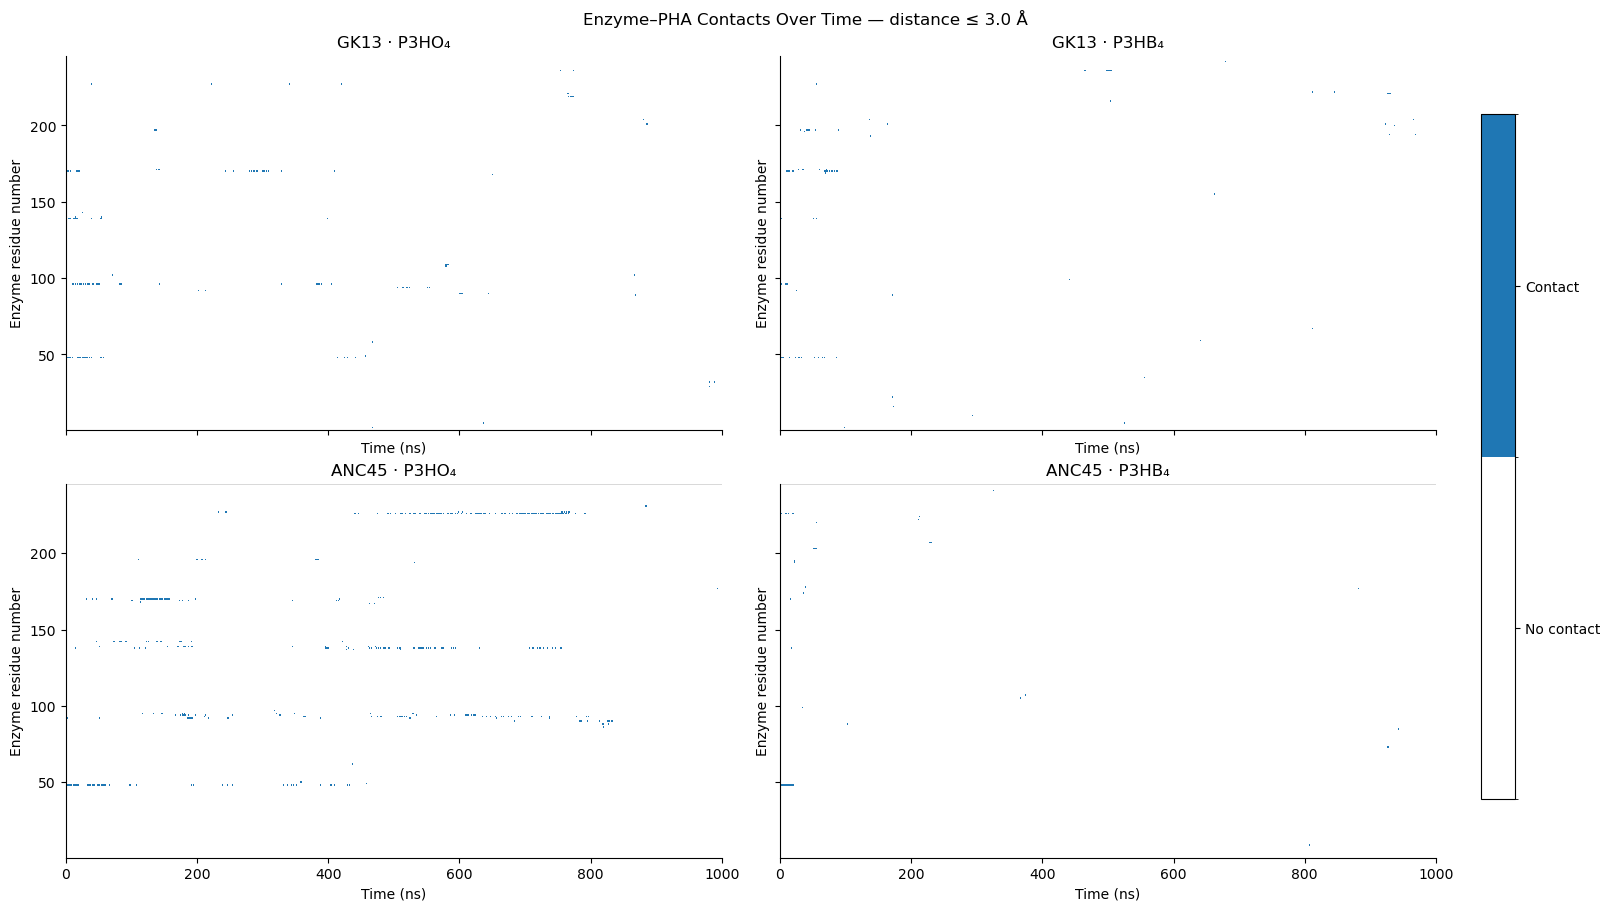

In [7]:
contact_cmap = ListedColormap(["white", "tab:blue"])
contact_cmap.set_bad("0.85")
contact_norm = BoundaryNorm([-0.5, 0.5, 1.5], contact_cmap.N)

for cutoff in RESIDUE_CUTOFFS_A:
    tag = residue_cutoff_tag(cutoff)
    fig, axes = plt.subplots(2, 2, figsize=PANEL_FIGSIZE, sharex=True, sharey=True, layout="constrained")
    manifest = []
    residue_min = min(int(residues.resid.min()) for _, residues, _ in residue_cache.values())
    residue_max = max(int(residues.resid.max()) for _, residues, _ in residue_cache.values())
    residue_numbers = np.arange(residue_min, residue_max + 1)
    residue_edges = np.arange(residue_min - 0.5, residue_max + 1.5)
    for ax, system in zip(axes.flat, RESIDUE_SYSTEMS):
        data, residues, metadata = residue_cache[system]
        times = data.time_ns.to_numpy()
        time_edges = np.r_[START_NS, (times[:-1] + times[1:]) / 2, END_NS]
        contacts = (data[residues.distance_column].to_numpy() <= cutoff).astype(np.uint8)
        grid = np.ma.masked_all((len(residue_numbers), len(times)), dtype=np.uint8)
        grid[residues.resid.to_numpy(dtype=int) - residue_min, :] = contacts.T
        mesh = ax.pcolormesh(time_edges, residue_edges, grid, cmap=contact_cmap,
                             norm=contact_norm, shading="flat", rasterized=True)
        ax.set(title=residue_panel_title(system), xlabel="Time (ns)", ylabel="Enzyme residue number",
               xlim=(START_NS, END_NS), ylim=(residue_min-0.5, residue_max+0.5))
        contact_path = Path(f"{residue_paths(system)['prefix']}_residue_pha_contacts_{tag}A.csv")
        if SAVE_RESIDUE_FIGURES:
            binary = pd.DataFrame(contacts, columns=residues.distance_column.str.removesuffix("_A") + "_contact")
            binary.insert(0, "time_ns", times)
            binary.insert(0, "frame", data.frame.to_numpy())
            binary.to_csv(contact_path, index=False)
        manifest.append({"system": system, "cutoff_A": cutoff, "contact_csv": str(contact_path),
                         "residue_identifiers_csv": str(residue_paths(system)["residues"]),
                         "distance_csv": str(residue_paths(system)["distances"]),
                         "frames": len(data), "residues": len(residues), "start_ns": times[0], "end_ns": times[-1],
                         "resid_min": int(residues.resid.min()), "resid_max": int(residues.resid.max()),
                         "sample_spacing_min_ns": float(np.diff(times).min()),
                         "sample_spacing_max_ns": float(np.diff(times).max()),
                         "no_contact_sample_count": int((contacts.sum(axis=1) == 0).sum()),
                         "definition": "1 if residue minimum heavy-atom PBC distance <= cutoff, otherwise 0",
                         "map_time_cells": "midpoints between actual sample timestamps, clipped to full window"})
    fig.suptitle(f"Enzyme–PHA Contacts Over Time — distance ≤ {cutoff:.1f} Å")
    colourbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), ticks=[0, 1], fraction=0.025, pad=0.02)
    colourbar.ax.set_yticklabels(["No contact", "Contact"])
    if SAVE_RESIDUE_FIGURES:
        RESIDUE_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
        prefix = RESIDUE_COMPARISON_DIR / f"enzyme_pha_{OUTPUT_TAG}_figure6_contacts_over_time_{tag}A"
        pd.DataFrame(manifest).to_csv(f"{prefix}.csv", index=False)
        fig.savefig(f"{prefix}.png", dpi=PNG_DPI)
        print(f"Saved {prefix}.png and .csv (index to the four full binary tables)")
    display(fig)
    plt.close(fig)


### New output files and rerunning

Each system's own `analysis/` folder contains `<system>_<OUTPUT_TAG>_residue_pha_`:
- `distances_A.csv`: one row per sampled frame, `frame`, `time_ns` and one Å distance column per residue.
- `residues.csv`: mapping from distance columns to the actual residue/segment identities and selected heavy atoms.
- `metadata.json`: settings, sampling interval, units, input provenance and numerical checks.
- `occupancy_3p5A.csv` / `occupancy_3p0A.csv`: residue occupancies and within times over the full window.
- `contacts_3p5A.csv` / `contacts_3p0A.csv`: full binary time series; zeros include all contact-free periods.

The four combined PNGs, aggregate occupancy tables and contact-table indexes are in the shared `PHA_Enzyme/analysis/`, named `enzyme_pha_<OUTPUT_TAG>_figure5_...` and `..._figure6_...`, with `3p5A` or `3p0A` in the filenames. Each four-panel figure is 16 × 9 inches at the existing 400 dpi, keeping each panel at the original figure size.

For cutoff/style changes: run the two original **settings cells only**, then **7. Residue settings**, **7b. Load saved data**, and **Figure 5 or 6**. Keep `RUN_RESIDUE_CALCULATION=False`; Figures 1–4 are not needed. `SAVE_RESIDUE_FIGURES=False` previews without writing new plot files. Changing trajectory sampling/selections requires an explicitly new residue calculation, and the sampling must agree with the corresponding saved Figure 3 data.

Figure 5 identifies residues most often near PHA. Figure 6 shows whether the same residue contacts persist, switch, recur or disappear. One trajectory per system supports descriptive comparisons only. Thresholds define geometric proximity, not hydrogen-bond identity or binding affinity. [MDAnalysis periodic distance arrays](https://docs.mdanalysis.org/stable/documentation_pages/lib/distances.html) use the frame's box for the minimum-image convention.

## 10. Residues with the highest PHA contact occupancy and VMD inspection frames

Reuse the validated **Figures 5–6 residue distance cache**; no trajectory distances or Figures 1–6 are recalculated. After restarting the kernel, run **1. Paths**, **5. Plot settings**, **7. Residue settings**, **7b. Load saved data**, then this section. Keep both trajectory-calculation flags `False`. The last cell saves only the two new tables in each system's existing `analysis/` folder. Existing different tables are protected; identical reruns are allowed.

Contact means **minimum residue–PHA heavy-atom PBC distance ≤3.5 Å**, using the saved `protein` / `resname LIG`, TPR mass >3 u selections and each frame's original box. Each residue is counted once per sample. Occupancy is the existing timestamp-weighted, linearly interpolated contact time divided by the **full 0–1000 ns duration**, including separation. The caches have **10,001 samples at 0.1 ns (100 ps) spacing**, saved frames 0–10000; this is measured again below rather than inferred from the current stride setting.

A contact interval contains one consecutive run of contacting samples. At an entry or exit, its boundary is the linear crossing between the neighbouring raw distances; intervals touching 0 or 1000 ns are clipped there. Every sampled non-contact breaks a run, even a single sample. These are **estimated intervals**, not observations of continuous contact between samples; shorter unobserved breaks or contacts cannot be resolved. An isolated sample exactly at the cutoff can have zero estimated duration.

Rank the top 10 by unrounded occupancy, breaking exact ties by ascending topology `resindex`. For equal longest durations (within 10⁻⁹ ns), take the earliest interval. Choose an **actual contacting sample** nearest its midpoint; midpoint ties (within 10⁻⁹ ns) go to the earlier time, then lower saved frame index. Residues without contacting samples have blank interval/frame fields.

The small frame tables use descriptive, reproducible criteria on these ten residues:

- **Typical:** the longest consecutive sampled run with at least three leading residues contacting at every sample, spanning at least 1 ns. Within that run, choose its most frequent exact contact pattern, then the sample nearest the run midpoint. Ties favour earlier times. No non-contact sample is bridged; the membership may vary within the run.
- **Change:** compare neighbouring, fixed 5 ns windows using the same interpolated occupancy method. Require at least one residue lost (≥70% to ≤30%) and another gained (≤30% to ≥70%). Choose the pair with the most such changes, then greatest summed occupancy contrast, then earliest boundary. Each selected sample must show the relevant lost/gained residues present/absent on the appropriate side. Other contacts are listed only if present in that sample.
- **Return:** look for the same sustained core (residues with ≥70% window occupancy; at least two residues) in two non-neighbouring 5 ns windows, with an intervening window showing at least one core residue lost (≤30%) and a different residue gained (≥70%, but ≤30% in both the earlier and return windows). Shared contacts may persist. Choose the earliest qualifying return, then earliest earlier/away windows. Show earlier, away and return samples so the recurrence is reviewable. This is a return of the leading-residue core, not a claim of the same molecular pose.

For change/return windows, eligible samples minimise the number of differences from the window's ≥70% core, then distance to the window midpoint, then time/frame index. Window summaries do not merge residue contact intervals. A missing qualifying typical/change/return is explicitly reported rather than forced. Frame selection never minimises the overall enzyme–PHA distance. These are **residues with the highest PHA contact occupancy**, not automatic assignments of catalytic function, hydrogen bonding or stronger binding.

In [5]:
CONTACT_CUTOFF_A = 3.5
LEADING_COUNT = 10
MIN_SUSTAINED_NS = 1.0
PATTERN_WINDOW_NS = 5.0
CORE_FRACTION = 0.70
ABSENT_FRACTION = 0.30
SAVE_LEADING_TABLES = True  # False previews; True saves only these two new tables per system.
INTERVAL_TIE_NS = 1e-9

if RUN_ANALYSIS or RUN_RESIDUE_CALCULATION:
    raise ValueError("Keep both trajectory-calculation flags False for this saved-data section.")
if (START_NS, END_NS) != (0.0, 1000.0) or CONTACT_CUTOFF_A != 3.5:
    raise ValueError("This section requires the full 0–1000 ns window and 3.5 Å cutoff.")


def true_runs(mask):
    """Inclusive sample positions; each False sample splits the runs."""
    edges = np.diff(np.r_[False, np.asarray(mask, dtype=bool), False].astype(int))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1) - 1))


def estimated_contact_intervals(times, distances, cutoff=CONTACT_CUTOFF_A):
    """Return interpolated boundaries and the first/last actual contacting samples."""
    times, distances = np.asarray(times, float), np.asarray(distances, float)
    intervals = []
    for first, last in true_runs(distances <= cutoff):
        start, end = times[first], times[last]
        if first > 0:
            start = times[first-1] + (times[first] - times[first-1]) * (
                (cutoff - distances[first-1]) / (distances[first] - distances[first-1]))
        if last < len(times)-1:
            end = times[last] + (times[last+1] - times[last]) * (
                (cutoff - distances[last]) / (distances[last+1] - distances[last]))
        intervals.append((float(start), float(end), int(first), int(last)))
    return intervals


def nearest_sample(positions, midpoint, times, frames):
    positions = np.asarray(positions, dtype=int)
    error = np.abs(times[positions] - midpoint)
    tied = positions[np.isclose(error, error.min(), atol=INTERVAL_TIE_NS, rtol=0)]
    return int(min(tied, key=lambda j: (times[j], frames[j])))


def residue_label(row):
    segment = f" [{row.segid}]" if row.segid else ""
    return f"{row.resname}{int(row.resid)}{segment}"


def verified_vmd_structure(system, residues, metadata):
    """Read GRO identifiers only; no trajectory frames or distances are calculated."""
    structure = BASE_DIR / system / "step7_production.gro"
    with structure.open() as handle:
        next(handle)
        atom_count = int(next(handle))
        atoms = [(int(line[:5]), line[5:10].strip(), line[10:15].strip())
                 for line in (next(handle) for _ in range(atom_count))]
    if atom_count != metadata["counts"]["system_atoms"]:
        raise ValueError(f"{system}: GRO and cached topology atom counts differ.")
    # Cached heavy-atom indices also verify identifiers at the expected atom positions.
    protein_ids = metadata["protein_heavy_atom_indices"]
    offset = 0
    for row in residues.itertuples(index=False):
        count = int(row.heavy_atom_count)
        observed = [atoms[j] for j in protein_ids[offset:offset+count]]
        expected = [(int(row.resid), row.resname, name) for name in row.heavy_atom_names.split()]
        if observed != expected:
            raise ValueError(f"{system}: GRO residue/atom order differs for {residue_label(row)}.")
        offset += count
    assert offset == len(protein_ids)
    pha_keys = {(int(row["resid"]), row["resname"]) for row in metadata["pha_identity"]}
    assert all(atoms[j][:2] in pha_keys for j in metadata["pha_heavy_atom_indices"])
    # A GRO has no chain/segment fields. Verify every residue/name pair is unique
    # across contiguous residue blocks before using it without a segment qualifier.
    blocks = []
    for resid, resname, _ in atoms:
        if not blocks or blocks[-1] != (resid, resname):
            blocks.append((resid, resname))
    from collections import Counter
    counts = Counter(blocks)
    assert all(counts[(int(row.resid), row.resname)] == 1 for row in residues.itertuples())
    return structure


def leading_residue_table(data, residues):
    times, frames = data.time_ns.to_numpy(), data.frame.to_numpy(dtype=int)
    durations = np.array([residue_duration_within_cutoff(times, data[c], CONTACT_CUTOFF_A)
                          for c in residues.distance_column])
    all_ranked = residues.assign(contact_time_ns=durations,
                                 occupancy_percent=100 * durations / (END_NS-START_NS))
    all_ranked = all_ranked.sort_values(["occupancy_percent", "resindex"], ascending=[False, True])
    top = all_ranked.head(LEADING_COUNT).copy().reset_index(drop=True)
    top.insert(0, "rank", np.arange(1, len(top)+1))
    details = []
    for row in top.itertuples(index=False):
        distances = data[row.distance_column].to_numpy()
        intervals = estimated_contact_intervals(times, distances)
        assert np.isclose(sum(b-a for a,b,_,_ in intervals), row.contact_time_ns, atol=1e-8, rtol=0)
        if intervals:
            maximum = max(b-a for a,b,_,_ in intervals)
            a,b,first,last = next(x for x in intervals if np.isclose(x[1]-x[0], maximum,
                                                                   atol=INTERVAL_TIE_NS, rtol=0))
            pos = nearest_sample(np.arange(first, last+1), (a+b)/2, times, frames)
            assert a-1e-9 <= times[pos] <= b+1e-9 and distances[pos] <= CONTACT_CUTOFF_A
            assert (distances[first:last+1] <= CONTACT_CUTOFF_A).all()
            details.append((a,b,b-a,times[pos],frames[pos],distances[pos]))
        else:
            details.append((np.nan,)*6)
    fields = ["longest_start_ns", "longest_end_ns", "longest_duration_ns",
              "representative_time_ns", "saved_frame_index", "representative_distance_A"]
    top[fields] = pd.DataFrame(details, columns=fields)
    top["saved_frame_index"] = top.saved_frame_index.astype("Int64")
    top["analysed_duration_ns"] = END_NS-START_NS
    top["cutoff_A"] = CONTACT_CUTOFF_A
    return top, all_ranked


# Analytic checks: uneven sampling, one-sample gap, equality, endpoints, no contacts.
assert estimated_contact_intervals([0,3,10], [2,2,5]) == [(0.0,6.5,0,1)]
assert estimated_contact_intervals([0,1,2], [2,5,2]) == [(0.0,0.5,0,0),(1.5,2.0,2,2)]
assert estimated_contact_intervals([0,1,2], [5,3.5,5]) == [(1.0,1.0,1,1)]
assert estimated_contact_intervals([0,10], [3.5,3.5]) == [(0.0,10.0,0,1)]
assert estimated_contact_intervals([0,10], [5,5]) == []
assert nearest_sample([0,1], 0.5, np.array([0.,1.]), np.array([17,29])) == 0

In [6]:
def representative_frame_table(data, top):
    times, frames = data.time_ns.to_numpy(), data.frame.to_numpy(dtype=int)
    distances = data[top.distance_column].to_numpy()
    contacts = distances <= CONTACT_CUTOFF_A
    labels = [residue_label(row) for row in top.itertuples()]
    rows, notes = [], []

    def label_set(mask):
        return "; ".join(label for label, yes in zip(labels, mask) if yes) or "none"

    def add_frame(role, pos, start, end, reason, window_fraction=None):
        rows.append({"role": role, "time_ns": float(times[pos]),
                     "saved_frame_index": int(frames[pos]),
                     "contacting_leading_residues": label_set(contacts[pos]),
                     "contacting_leading_count": int(contacts[pos].sum()),
                     "contact_distances_A": json.dumps({labels[k]: float(distances[pos,k])
                                                       for k in np.flatnonzero(contacts[pos])}),
                     "evidence_start_ns": float(start), "evidence_end_ns": float(end),
                     "window_occupancy_percent": (json.dumps(dict(zip(labels, (100*window_fraction).tolist())))
                                                   if window_fraction is not None else ""),
                     "reason": reason})

    # Typical sample: sustained sampled co-contact, then the most frequent exact pattern.
    sustained = [(a,b) for a,b in true_runs(contacts.sum(axis=1) >= 3)
                 if times[b]-times[a] >= MIN_SUSTAINED_NS-1e-9]
    if sustained:
        maximum = max(times[b]-times[a] for a,b in sustained)
        first,last = next((a,b) for a,b in sustained
                          if np.isclose(times[b]-times[a], maximum, atol=INTERVAL_TIE_NS, rtol=0))
        patterns, counts = np.unique(contacts[first:last+1], axis=0, return_counts=True)
        candidates = np.flatnonzero(np.any(np.all(
            contacts[first:last+1,None,:] == patterns[counts == counts.max()][None,:,:], axis=2), axis=1)) + first
        pos = nearest_sample(candidates, (times[first]+times[last])/2, times, frames)
        pattern_count = int(np.all(contacts[first:last+1] == contacts[pos], axis=1).sum())
        add_frame("typical", pos, times[first], times[last],
                  f"Longest sampled run with ≥3 leading contacts at every sample: {times[first]:g}–{times[last]:g} ns "
                  f"({times[last]-times[first]:g} ns, {last-first+1} samples). "
                  f"Modal exact pattern occurs in {pattern_count}/{last-first+1} samples; nearest its run midpoint.")
    else:
        notes.append("No typical frame: no ≥1 ns sampled run with at least three leading contacts throughout.")

    # Integrate each fixed window using inserted boundary distances, so crossings and
    # actual timestamps match Figure 5 even if samples do not lie on window boundaries.
    windows = []
    for start in np.arange(START_NS, END_NS, PATTERN_WINDOW_NS):
        end = min(start + PATTERN_WINDOW_NS, END_NS)
        inner = (times > start) & (times < end)
        window_times = np.r_[start, times[inner], end]
        fraction = np.array([residue_duration_within_cutoff(window_times,
            np.r_[np.interp(start,times,distances[:,k]), distances[inner,k],
                  np.interp(end,times,distances[:,k])], CONTACT_CUTOFF_A)/(end-start)
            for k in range(len(top))])
        # Half-open sample windows avoid assigning the same boundary sample twice.
        positions = np.flatnonzero((times >= start) & ((times < end) | ((end == END_NS) & (times == end))))
        windows.append({"start":start, "end":end, "fraction":fraction,
                        "core":fraction >= CORE_FRACTION, "positions":positions})

    def window_sample(window, present, absent):
        candidates = window["positions"]
        candidates = candidates[contacts[candidates][:,present].all(axis=1)
                                & (~contacts[candidates][:,absent]).all(axis=1)]
        if not len(candidates):
            return None
        errors = (contacts[candidates] != window["core"]).sum(axis=1)
        return nearest_sample(candidates[errors == errors.min()], (window["start"]+window["end"])/2, times, frames)

    changes = []
    for i, (before, after) in enumerate(zip(windows[:-1], windows[1:])):
        lost = (before["fraction"] >= CORE_FRACTION) & (after["fraction"] <= ABSENT_FRACTION)
        gained = (before["fraction"] <= ABSENT_FRACTION) & (after["fraction"] >= CORE_FRACTION)
        if not lost.any() or not gained.any():
            continue
        left = window_sample(before, lost, gained)
        right = window_sample(after, gained, lost)
        if left is not None and right is not None:
            changes.append((int(lost.sum()+gained.sum()),
                            float(np.abs(before["fraction"]-after["fraction"]).sum()), i, left, right, lost, gained))
    if changes:
        _,_,i,left,right,lost,gained = sorted(changes, key=lambda item: (-item[0],-item[1],item[2]))[0]
        for role,pos,window in [("before_change",left,windows[i]), ("after_change",right,windows[i+1])]:
            reason = (f"Adjacent 5 ns windows at {windows[i]['end']:g} ns: lost {label_set(lost)} "
                      f"(≥70% → ≤30%); gained {label_set(gained)} (≤30% → ≥70%). "
                      "This sample shows those presences/absences; other listed contacts are sample-specific.")
            add_frame(role,pos,window["start"],window["end"],reason,window["fraction"])
    else:
        notes.append("No clear change under the adjacent 5 ns, ≥70%/≤30% loss-and-gain criterion.")

    # Earliest supported A -> B -> A recurrence; shared residues may persist.
    recurrence = None
    for k, returned in enumerate(windows):
        if returned["core"].sum() < 2:
            continue
        for i in range(k-1):
            earlier = windows[i]
            if not np.array_equal(earlier["core"], returned["core"]):
                continue
            anchor = returned["core"]
            for j in range(i+1,k):
                away = windows[j]
                lost = anchor & (away["fraction"] <= ABSENT_FRACTION)
                gained = (away["core"] & (earlier["fraction"] <= ABSENT_FRACTION)
                          & (returned["fraction"] <= ABSENT_FRACTION))
                if not lost.any() or not gained.any():
                    continue
                earlier_pos = window_sample(earlier, anchor, gained)
                return_pos = window_sample(returned, anchor, gained)
                away_pos = window_sample(away, gained, lost)
                if all(pos is not None for pos in (earlier_pos, away_pos, return_pos)):
                    recurrence = (i,j,k,earlier_pos,away_pos,return_pos,anchor,lost,gained)
                    break
            if recurrence is not None:
                break
        if recurrence is not None:
            break
    if recurrence is not None:
        i,j,k,earlier_pos,away_pos,return_pos,anchor,lost,gained = recurrence
        for role,pos,window in [("earlier_pattern",earlier_pos,windows[i]),
                                ("intervening_pattern",away_pos,windows[j]),
                                ("return",return_pos,windows[k])]:
            reason = (f"Core {label_set(anchor)} has ≥70% occupancy in {windows[i]['start']:g}–{windows[i]['end']:g} "
                      f"and {windows[k]['start']:g}–{windows[k]['end']:g} ns. In "
                      f"{windows[j]['start']:g}–{windows[j]['end']:g} ns, {label_set(lost)} falls to ≤30%, "
                      f"while {label_set(gained)} rises to ≥70% (≤30% in both other windows). "
                      "Samples show this exchange and recovery; shared contacts may persist.")
            add_frame(role,pos,window["start"],window["end"],reason,window["fraction"])
    else:
        notes.append("No supported return of a ≥2-residue sustained core with an intervening residue exchange under these criteria.")

    columns = ["role", "time_ns", "saved_frame_index", "contacting_leading_residues",
               "contacting_leading_count", "contact_distances_A", "evidence_start_ns", "evidence_end_ns",
               "window_occupancy_percent", "reason"]
    table = pd.DataFrame(rows, columns=columns)
    # Validate every reported identity/distance and time against the saved frame mapping.
    for row in table.itertuples(index=False):
        pos, = np.flatnonzero(frames == row.saved_frame_index)
        assert times[pos] == row.time_ns
        assert row.contacting_leading_residues == label_set(contacts[pos])
        assert row.contacting_leading_count == int(contacts[pos].sum())
        assert json.loads(row.contact_distances_A) == {labels[k]: float(distances[pos,k])
                                                     for k in np.flatnonzero(contacts[pos])}
        assert row.evidence_start_ns <= row.time_ns <= row.evidence_end_ns
    return table, notes

### 10a. Validate, display and save the two tables per system

The cell below checks cached hashes/provenance, validates interval integrals against the existing occupancy helper and saved Figure 5 table, and checks the complete binary classifications against Figure 6. It verifies each chosen frame's time, residue list and distances against its **saved frame index**, not its CSV row number. The new CSVs retain unrounded numerical values; displayed interval estimates use six decimal places for reproducibility, not a claim of sub-sample temporal accuracy.

For VMD, use the printed `step7_production.gro` structure with the corresponding **full** `analysis/processed_protein_centered.xtc`; the calculation topology was `step7_production.tpr`. The GRO atom count, protein residue names/numbers/heavy-atom names and their cached atom indices, and PHA identifiers are checked below. Chain identifiers are not stored in the cache or GRO. `seg_0_PROA` is the cached MDAnalysis segment and is retained in the tables; it must not be assumed to be VMD's `segname`. The printed [VMD selection expressions](https://www.ks.uiuc.edu/Research/vmd/current/ug/node89.html) use `resid` and `resname` pairs verified to be unique in this GRO. They select the full leading residues for inspection; the contact calculation itself used heavy atoms only.

**Check VMD numbering against the files actually loaded.** Saved frame indices are zero-based indices in the full processed XTC. Loading a GRO may add a reference coordinate frame; loading only part of an XTC or using a stride changes the mapping. If XTC frame `f0` is the first loaded, stride is `s`, and `nref` frames precede it, the candidate VMD index is `nref + (saved_frame_index - f0)/s` **only when that quotient is a non-negative integer and the frame was loaded**. Verify these conditions and the loaded time/frame mapping; do not assume saved and VMD indices match. The `every100` preview generally omits selected samples.

**Periodic images:** display PHA in the appropriate periodic image relative to the enzyme (using the same frame's box) to agree with the minimum-image distances. A centred trajectory can still show PHA across a boundary; raw displayed separations can disagree until the image is corrected. No molecular images are generated here.

In [7]:
from IPython.display import Markdown

leading_contact_results = {}
leading_export_payloads = {}
for system in RESIDUE_SYSTEMS:
    # Reload and revalidate the saved cache, even if a previous kernel cache exists.
    data, residues, metadata = load_residue_distances(system)
    times, frames = data.time_ns.to_numpy(), data.frame.to_numpy(dtype=int)
    assert np.all(np.diff(times) > 0) and np.all(np.diff(frames) > 0)
    assert metadata["sample_count"] == len(data)
    assert metadata["pbc"] == "minimum image with each frame's original box; unaligned coordinates"
    assert metadata["distance_definition"] == "minimum over residue heavy atoms and all PHA heavy atoms"
    structure = verified_vmd_structure(system, residues, metadata)
    top, ranked = leading_residue_table(data, residues)
    assert len(top) == LEADING_COUNT and top.resindex.is_unique
    assert top.occupancy_percent.between(0,100).all()
    assert np.allclose(top.occupancy_percent, 100*top.contact_time_ns/(END_NS-START_NS), atol=1e-10, rtol=0)
    assert np.all(top.longest_duration_ns <= top.contact_time_ns+1e-8)
    prefix = residue_paths(system)["prefix"]

    # Compare to prior results without recalculating or rewriting either figure.
    old_occupancy = pd.read_csv(f"{prefix}_residue_pha_occupancy_3p5A.csv").set_index("distance_column")
    expected = old_occupancy.loc[ranked.distance_column]
    assert np.allclose(expected.within_time_ns, ranked.contact_time_ns, atol=1e-8, rtol=0)
    assert np.allclose(expected.percent_within, ranked.occupancy_percent, atol=1e-8, rtol=0)
    assert np.allclose(expected.total_time_ns, END_NS-START_NS, atol=1e-8, rtol=0)
    binary = pd.read_csv(f"{prefix}_residue_pha_contacts_3p5A.csv")
    assert np.array_equal(binary.frame, frames) and np.allclose(binary.time_ns, times, atol=1e-8, rtol=0)
    contact_columns = residues.distance_column.str.removesuffix("_A") + "_contact"
    assert np.array_equal(binary[contact_columns].to_numpy(), data[residues.distance_column].to_numpy() <= CONTACT_CUTOFF_A)

    frame_table, notes = representative_frame_table(data, top)
    vmd_selection = " or ".join(f"(resid {int(row.resid)} and resname {row.resname})" for row in top.itertuples())
    steps = np.diff(times)
    top["vmd_residue_selection"] = [f"resid {int(row.resid)} and resname {row.resname}" for row in top.itertuples()]
    for table in (top, frame_table):
        table.insert(0, "system", system.removesuffix("_gromacs"))
        table["source_distances"] = str(residue_paths(system)["distances"])
        table["structure_file"] = str(structure)
        table["topology_file"] = metadata["inputs"]["tpr"]
        table["trajectory_file"] = metadata["inputs"]["xtc"]
        table["sampling_interval_min_ns"] = float(steps.min())
        table["sampling_interval_max_ns"] = float(steps.max())
    frame_table["cutoff_A"] = CONTACT_CUTOFF_A
    frame_table["selection_notes"] = " ".join(notes)
    frame_table["vmd_leading_selection"] = vmd_selection
    top["interval_method"] = "linear cutoff crossings; split at every non-contact sample; full elapsed denominator"
    ranking_path = Path(f"{prefix}_residue_pha_top10_occupancy_3p5A.csv")
    frames_path = Path(f"{prefix}_residue_pha_representative_frames_3p5A.csv")
    leading_export_payloads[ranking_path] = top.to_csv(index=False)
    leading_export_payloads[frames_path] = frame_table.to_csv(index=False)
    leading_contact_results[system] = (top, frame_table, notes)

    display(Markdown(f"**{residue_panel_title(system)} — residues with the highest PHA contact occupancy**"))
    print(f"{len(data):,} samples; {times[0]:g}–{times[-1]:g} ns; spacing {steps.min():g}–{steps.max():g} ns; "
          f"saved frames {frames[0]}–{frames[-1]}; denominator {END_NS-START_NS:g} ns.")
    print("Structure:", structure, "\nCalculation topology:", metadata["inputs"]["tpr"],
          "\nProcessed trajectory:", metadata["inputs"]["xtc"])
    print("VMD leading-residue selection (identifiers verified against GRO):\n" + vmd_selection)
    print("VMD PHA selection:", PHA_SELECTION)
    rank_columns = ["rank", "resname", "resid", "segid", "occupancy_percent", "contact_time_ns",
                    "longest_start_ns", "longest_end_ns", "longest_duration_ns", "representative_time_ns", "saved_frame_index"]
    frame_columns = ["role", "time_ns", "saved_frame_index", "contacting_leading_residues", "reason"]
    with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
        display(top[rank_columns].round(6))
        display(frame_table[frame_columns])
    for note in notes:
        print(note)
    print("Validated: all residue occupancies against Figure 5, all binary samples against Figure 6, "
          "top-10 interval sums, and every selected frame/time/contact list against the saved distances.")
    print("Table destinations:", ranking_path, frames_path, sep="\n")

# Preflight every destination before writing any file. Prior different results are protected.
for path, payload in leading_export_payloads.items():
    if not path.parent.is_dir() or path.is_symlink():
        raise ValueError(f"Require an existing analysis folder and a non-symlink output: {path}")
    if path.exists() and path.read_text() != payload:
        raise FileExistsError(f"Existing different table protected: {path}")
if SAVE_LEADING_TABLES:
    for path, payload in leading_export_payloads.items():
        if not path.exists():
            with path.open("x") as handle:
                handle.write(payload)
        assert path.read_text() == payload
        print(f"Saved/verified: {path}")
else:
    print("Preview only: all tables validated; set SAVE_LEADING_TABLES=True to save these eight new CSVs.")

**GK13 · P3HO₄ — residues with the highest PHA contact occupancy**

10,001 samples; 0–1000 ns; spacing 0.1–0.1 ns; saved frames 0–10000; denominator 1000 ns.
Structure: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step7_production.gro 
Calculation topology: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step7_production.tpr 
Processed trajectory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/processed_protein_centered.xtc
VMD leading-residue selection (identifiers verified against GRO):
(resid 96 and resname ASN) or (resid 170 and resname SER) or (resid 92 and resname PHE) or (resid 48 and resname SER) or (resid 139 and resname SER) or (resid 49 and resname PHE) or (resid 197 and resname VAL) or (resid 97 and resname ILE) or (resid 94 and resname GLN) or (resid 227 and resname HSD)
VMD PHA selection: resname LIG


,rank,resname,resid,segid,occupancy_percent,contact_time_ns,longest_start_ns,longest_end_ns,longest_duration_ns,representative_time_ns,saved_frame_index
0,1,ASN,96,seg_0_PROA,15.038841,150.388414,0.417948,4.375655,3.957707,2.4,24
1,2,SER,170,seg_0_PROA,13.136607,131.366066,284.502240,293.490738,8.988498,289.0,2890
2,3,PHE,92,seg_0_PROA,12.153747,121.537466,180.586627,181.585991,0.999364,181.1,1811
3,4,SER,48,seg_0_PROA,11.173117,111.731175,0.000000,22.775651,22.775651,11.4,114
4,5,SER,139,seg_0_PROA,9.909848,99.098476,0.000000,5.064385,5.064385,2.5,25
5,6,PHE,49,seg_0_PROA,6.501898,65.018976,455.626298,458.076303,2.450006,456.9,4569
6,7,VAL,197,seg_0_PROA,6.227305,62.273050,135.255754,137.644027,2.388273,136.4,1364
7,8,ILE,97,seg_0_PROA,4.344310,43.443100,411.146742,411.732705,0.585963,411.4,4114
8,9,GLN,94,seg_0_PROA,3.685391,36.853910,550.228253,554.576770,4.348518,552.4,5524
9,10,HSD,227,seg_0_PROA,3.411908,34.119083,339.880116,341.381692,1.501576,340.6,3406


,role,time_ns,saved_frame_index,contacting_leading_residues,reason
0,typical,9.6,96,ASN96 [seg_0_PROA]; SER170 [seg_0_PROA]; SER48 [seg_0_PROA]; SER139 [seg_0_PROA],"Longest sampled run with ≥3 leading contacts at every sample: 5.2–14.2 ns (9 ns, 91 samples). Modal exact pattern occurs in 26/91 samples; nearest its run midpoint."


No clear change under the adjacent 5 ns, ≥70%/≤30% loss-and-gain criterion.
No supported return of a ≥2-residue sustained core with an intervening residue exchange under these criteria.
Validated: all residue occupancies against Figure 5, all binary samples against Figure 6, top-10 interval sums, and every selected frame/time/contact list against the saved distances.
Table destinations:
/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/GK13_P3HO_4_research_0_1000ns_residue_pha_top10_occupancy_3p5A.csv
/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/GK13_P3HO_4_research_0_1000ns_residue_pha_representative_frames_3p5A.csv


...

**ANC45 · P3HB₄ — residues with the highest PHA contact occupancy**

10,001 samples; 0–1000 ns; spacing 0.1–0.1 ns; saved frames 0–10000; denominator 1000 ns.
Structure: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HB_4_gromacs/step7_production.gro 
Calculation topology: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HB_4_gromacs/step7_production.tpr 
Processed trajectory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HB_4_gromacs/analysis/processed_protein_centered.xtc
VMD leading-residue selection (identifiers verified against GRO):
(resid 48 and resname SER) or (resid 226 and resname HSD) or (resid 62 and resname PHE) or (resid 138 and resname SER) or (resid 196 and resname ILE) or (resid 105 and resname LEU) or (resid 50 and resname PHE) or (resid 103 and resname TYR) or (resid 203 and resname ASP) or (resid 47 and resname GLY)
VMD PHA selection: resname LIG


,rank,resname,resid,segid,occupancy_percent,contact_time_ns,longest_start_ns,longest_end_ns,longest_duration_ns,representative_time_ns,saved_frame_index
0,1,SER,48,seg_0_PROA,2.411031,24.110309,3.716501,21.512093,17.795592,12.6,126
1,2,HSD,226,seg_0_PROA,1.534768,15.347684,19.508132,20.939715,1.431582,20.2,202
2,3,PHE,62,seg_0_PROA,1.362758,13.627578,9.218923,10.089524,0.870601,9.7,97
3,4,SER,138,seg_0_PROA,1.204173,12.041732,0.150117,1.591186,1.441068,0.9,9
4,5,ILE,196,seg_0_PROA,1.070654,10.706535,3.824728,5.285557,1.460829,4.6,46
5,6,LEU,105,seg_0_PROA,1.044578,10.445781,365.811956,370.890432,5.078476,368.4,3684
6,7,PHE,50,seg_0_PROA,0.956615,9.566148,2.180385,2.980380,0.799994,2.6,26
7,8,TYR,103,seg_0_PROA,0.705690,7.056901,369.344712,371.277317,1.932605,370.3,3703
8,9,ASP,203,seg_0_PROA,0.685131,6.851307,49.671365,53.340994,3.669629,51.5,515
9,10,GLY,47,seg_0_PROA,0.623619,6.236193,13.772036,14.795439,1.023403,14.3,143


,role,time_ns,saved_frame_index,contacting_leading_residues,reason
0,typical,5.0,50,SER48 [seg_0_PROA]; PHE62 [seg_0_PROA]; SER138 [seg_0_PROA]; ILE196 [seg_0_PROA],"Longest sampled run with ≥3 leading contacts at every sample: 3.8–6.4 ns (2.6 ns, 27 samples). Modal exact pattern occurs in 3/27 samples; nearest its run midpoint."


No clear change under the adjacent 5 ns, ≥70%/≤30% loss-and-gain criterion.
No supported return of a ≥2-residue sustained core with an intervening residue exchange under these criteria.
Validated: all residue occupancies against Figure 5, all binary samples against Figure 6, top-10 interval sums, and every selected frame/time/contact list against the saved distances.
Table destinations:
/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HB_4_gromacs/analysis/ANC45_P3HB_4_research_0_1000ns_residue_pha_top10_occupancy_3p5A.csv
/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HB_4_gromacs/analysis/ANC45_P3HB_4_research_0_1000ns_residue_pha_representative_frames_3p5A.csv
Saved/verified: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/GK13_P3HO_4_research_0_1000ns_residue_pha_top10_occupancy_3p5A.csv
Saved/verified: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/